In [84]:
# Import packages
from pathlib import Path

project_dir = Path("/home/mcaskey/10XvParse/")
species = "hsapiens"
index_dir = project_dir / "Index" / "human"
analysis_name = "Analysis_6"
analysis_dir = Path.cwd() 

In [85]:
import matplotlib.pyplot as plt
import numpy as np
import scrublet as scr
import pandas as pd
import anndata as ad
import scanpy as sc

from XvP_utils import plotting

In [86]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [87]:
# # In case you change the package
# import importlib
# importlib.reload(plotting)

In [88]:
data_10x = plotting.init_processing(analysis_name=analysis_name, project_dir=project_dir, data_name='10x', assay ="10x", data_title='10X Genomics')
data_polyT = plotting.init_processing(analysis_name=analysis_name, project_dir=project_dir, data_name='polyT', assay="parse", data_title='Parse 3\'')
data_randO = plotting.init_processing(analysis_name=analysis_name, project_dir=project_dir, data_name='randO', assay="parse", data_title='Parse Random Oligo')
data_parse = plotting.init_processing(analysis_name=analysis_name, project_dir=project_dir, data_name='parse', assay="parse", data_title='Parse', modified=True)

raw_datasets = [data_10x, data_polyT, data_randO, data_parse]

In [89]:
go_df = pd.read_csv("/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv")
terms = ["Ribosome", "RNA Binding (GO:0003723)", "Translation (GO:0006412)", "Ribosome Biogenesis (GO:0042254)", "Oxidative Phosphorylation"]
go_df = go_df[go_df["Term"].isin(terms)]

In [90]:
genes_to_filter = []
for gene_list in go_df["Genes"]:
    genes_to_filter.extend(gene_list.split(";"))

genes_to_filter.append("MALAT1")
genes_to_filter = set(genes_to_filter)

In [92]:
truncated_datasets = []
for dataset in raw_datasets:
    truncated_dataset = dataset[:, ~dataset.var_names.str.startswith(tuple(genes_to_filter))].copy()
    truncated_dataset = plotting.refilter(truncated_dataset, min_counts=0)
    truncated_datasets.append(truncated_dataset)

# Population Upsampling Estimation

PreSeq running in background for: 10x
PreSeq output not ready for '10X Genomics' — skipping.


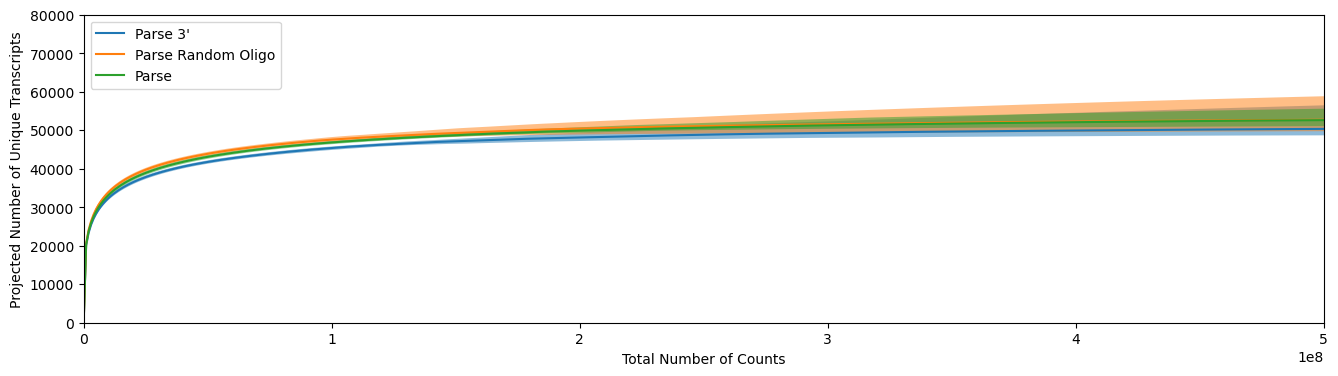

In [ ]:
# Launches PreSeq in the background — does not block the notebook.
# Rerun plot_upsample() in a later cell once jobs complete.
# plotting.upsample(raw_datasets, Path("preseq"), overwrite=False)
# plotting.plot_upsample(raw_datasets, Path("preseq"), xlim=5e8, ylim=8e4)

# Quality Control Comparison

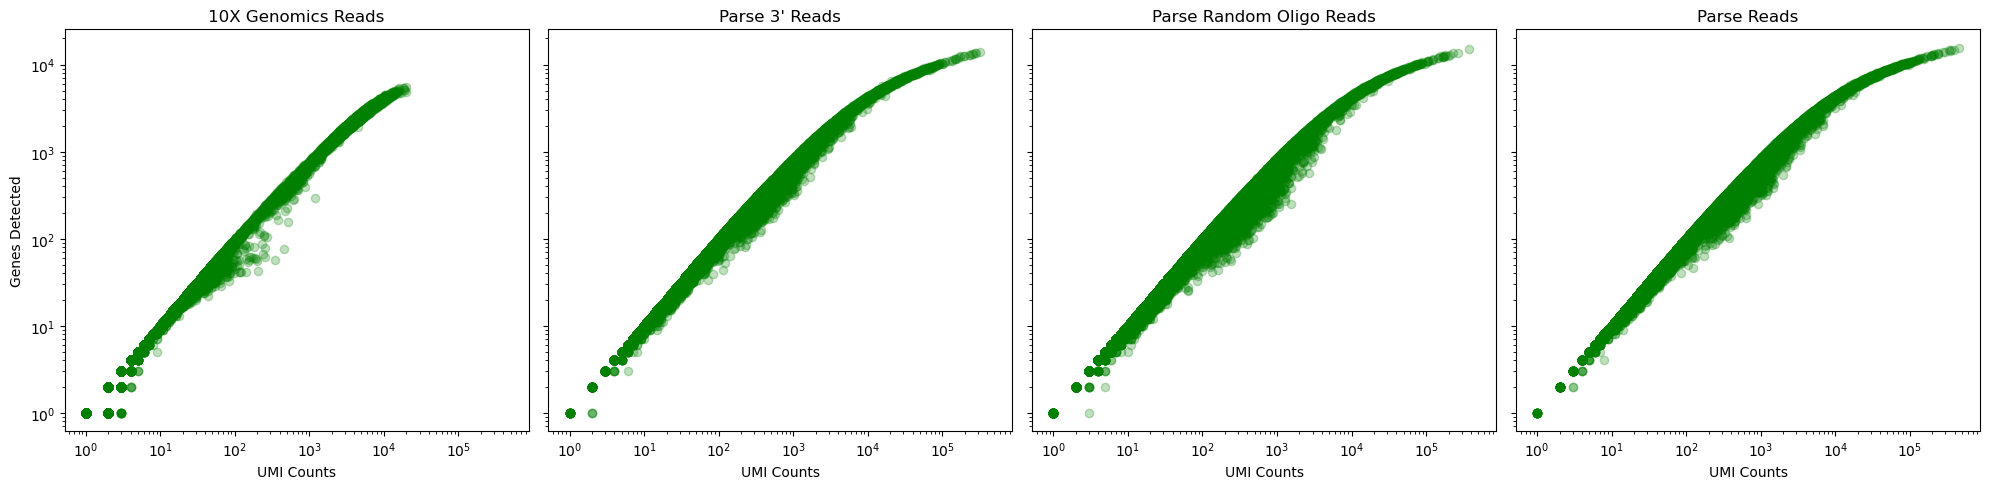

In [93]:
fig, ax = plt.subplots(1, 4, figsize=(20,5), sharey=True, sharex=True)

for i, data in enumerate(truncated_datasets):
    plotting.scatter_reads(ax[i], data)

ax[0].set_ylabel("Genes Detected")

plt.tight_layout()
plt.show()

In [94]:
# Path to save gene metadata so don't need to query Ensembl more than once
gene_info = plotting.query_ensembl(analysis_dir, index_dir=index_dir, overwrite=True)

In [95]:
for data in truncated_datasets:
    plotting.add_cell_metrics(data, gene_info)

/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:380: RuntimeWarning: invalid value encountered in divide
  data.obs['percent_pc'] = np.array(pc_counts / total_counts * 100).flatten()
/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:381: RuntimeWarning: invalid value encountered in divide
  data.obs['percent_mito'] = np.array(mito_counts / total_counts * 100).flatten()
/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:382: RuntimeWarning: invalid value encountered in divide
  data.obs['percent_ribo'] = np.array(ribo_counts / total_counts * 100).flatten()
/home/mcaskey/10XvParse/XvP_utils/plotting/processing.py:383: RuntimeWarning: invalid value encountered in divide
  data.obs['percent_lnc'] = np.array(lnc_counts / total_counts * 100).flatten()
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3

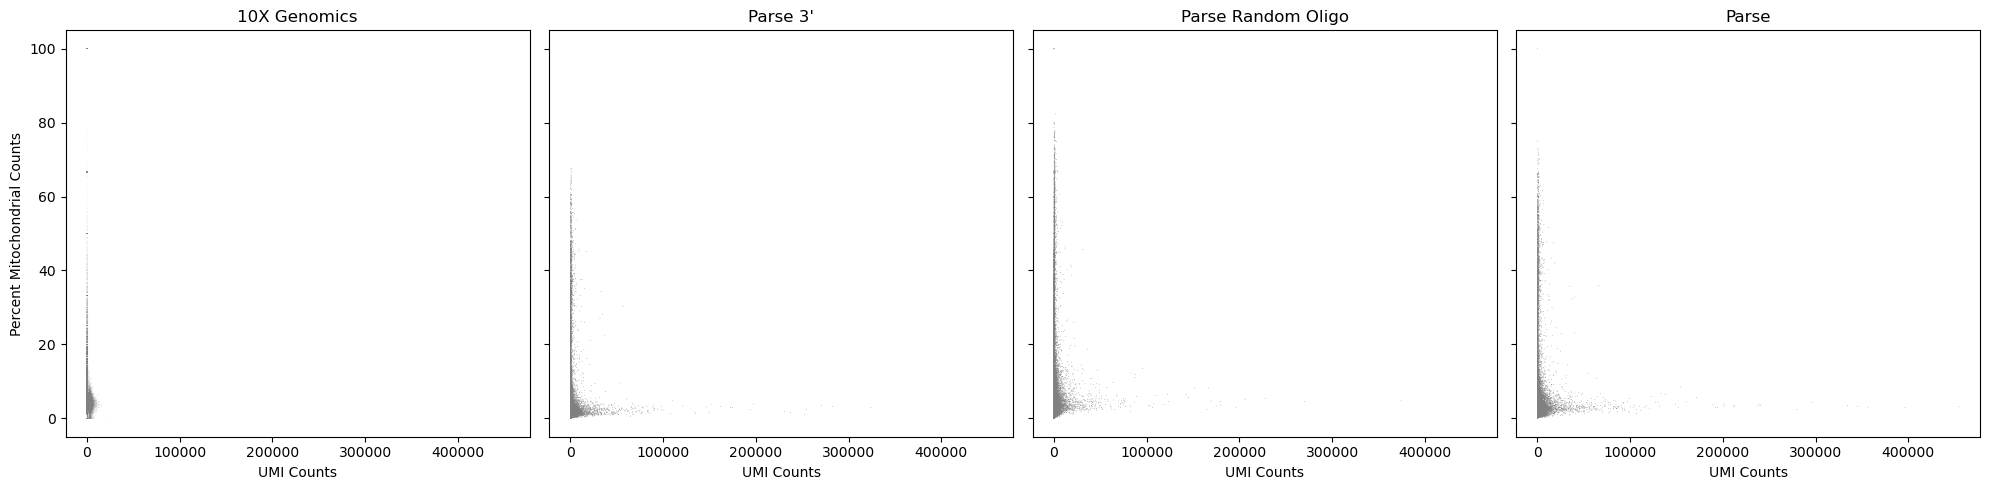

In [96]:
fig, ax = plt.subplots(1, 4, figsize=(20,5), sharey=True,sharex=True)
for i, data in enumerate(truncated_datasets):
    plotting.mito_scatter(ax[i], data)

ax[0].set_ylabel("Percent Mitochondrial Counts")

plt.tight_layout()
plt.show()

13,461 cells passed the 300 UMI threshold for 10X Genomics
10,268 cells passed the 400 UMI threshold for Parse 3'
8,882 cells passed the 400 UMI threshold for Parse Random Oligo
10,905 cells passed the 400 UMI threshold for Parse


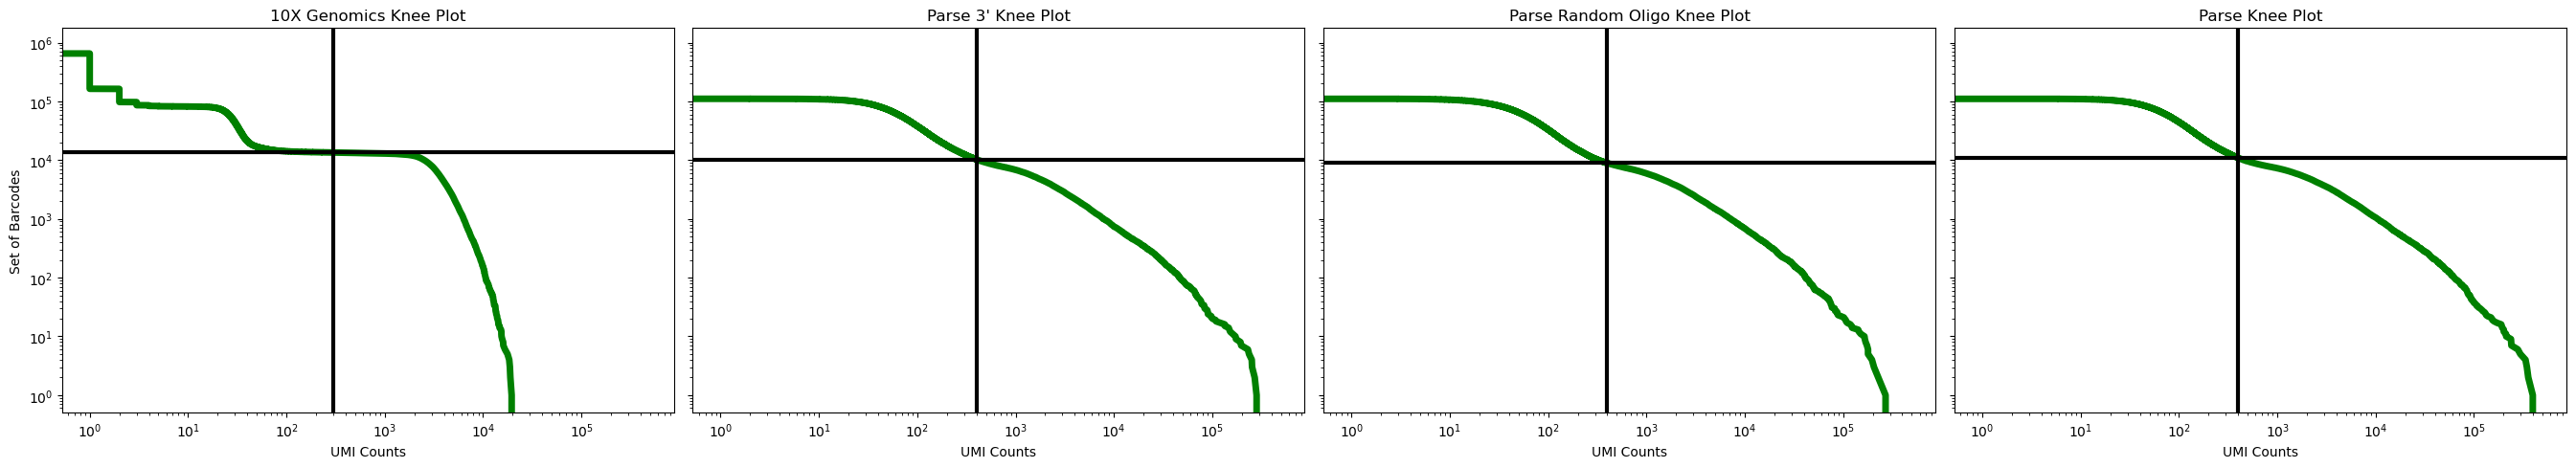

In [97]:
fig, ax = plt.subplots(1, 4, figsize=(27,5), sharey=True, sharex=True)

cutoffs = [300, 400, 400, 400]

datasets = []
for i, (data, cutoff) in enumerate(zip(truncated_datasets, cutoffs)):
    datasets.append(plotting.knee_plot(ax[i], data, cutoff=cutoff))

ax[0].set_ylabel("Set of Barcodes")

plt.tight_layout()
plt.show()

In [98]:
full_gene_info_path = project_dir / analysis_dir 
gene_info = plotting.update_gene_info(gene_info, datasets, full_gene_info_path)

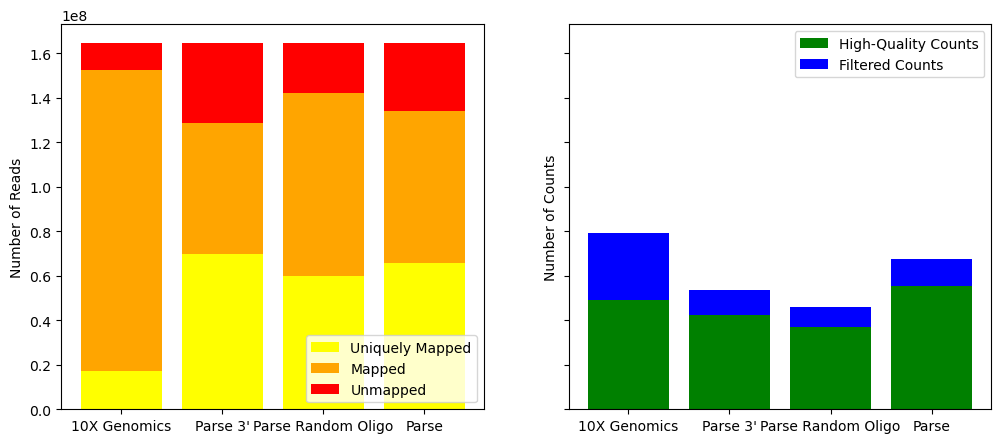

In [99]:
plotting.plot_filtering_metrics(datasets)

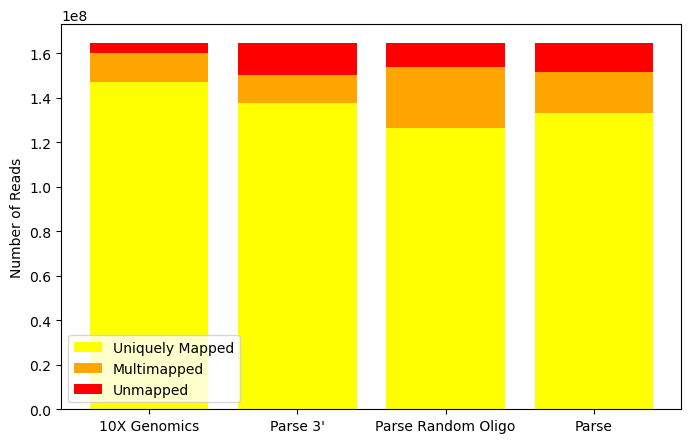

In [100]:
plotting.plot_filtering_metrics_star(datasets)

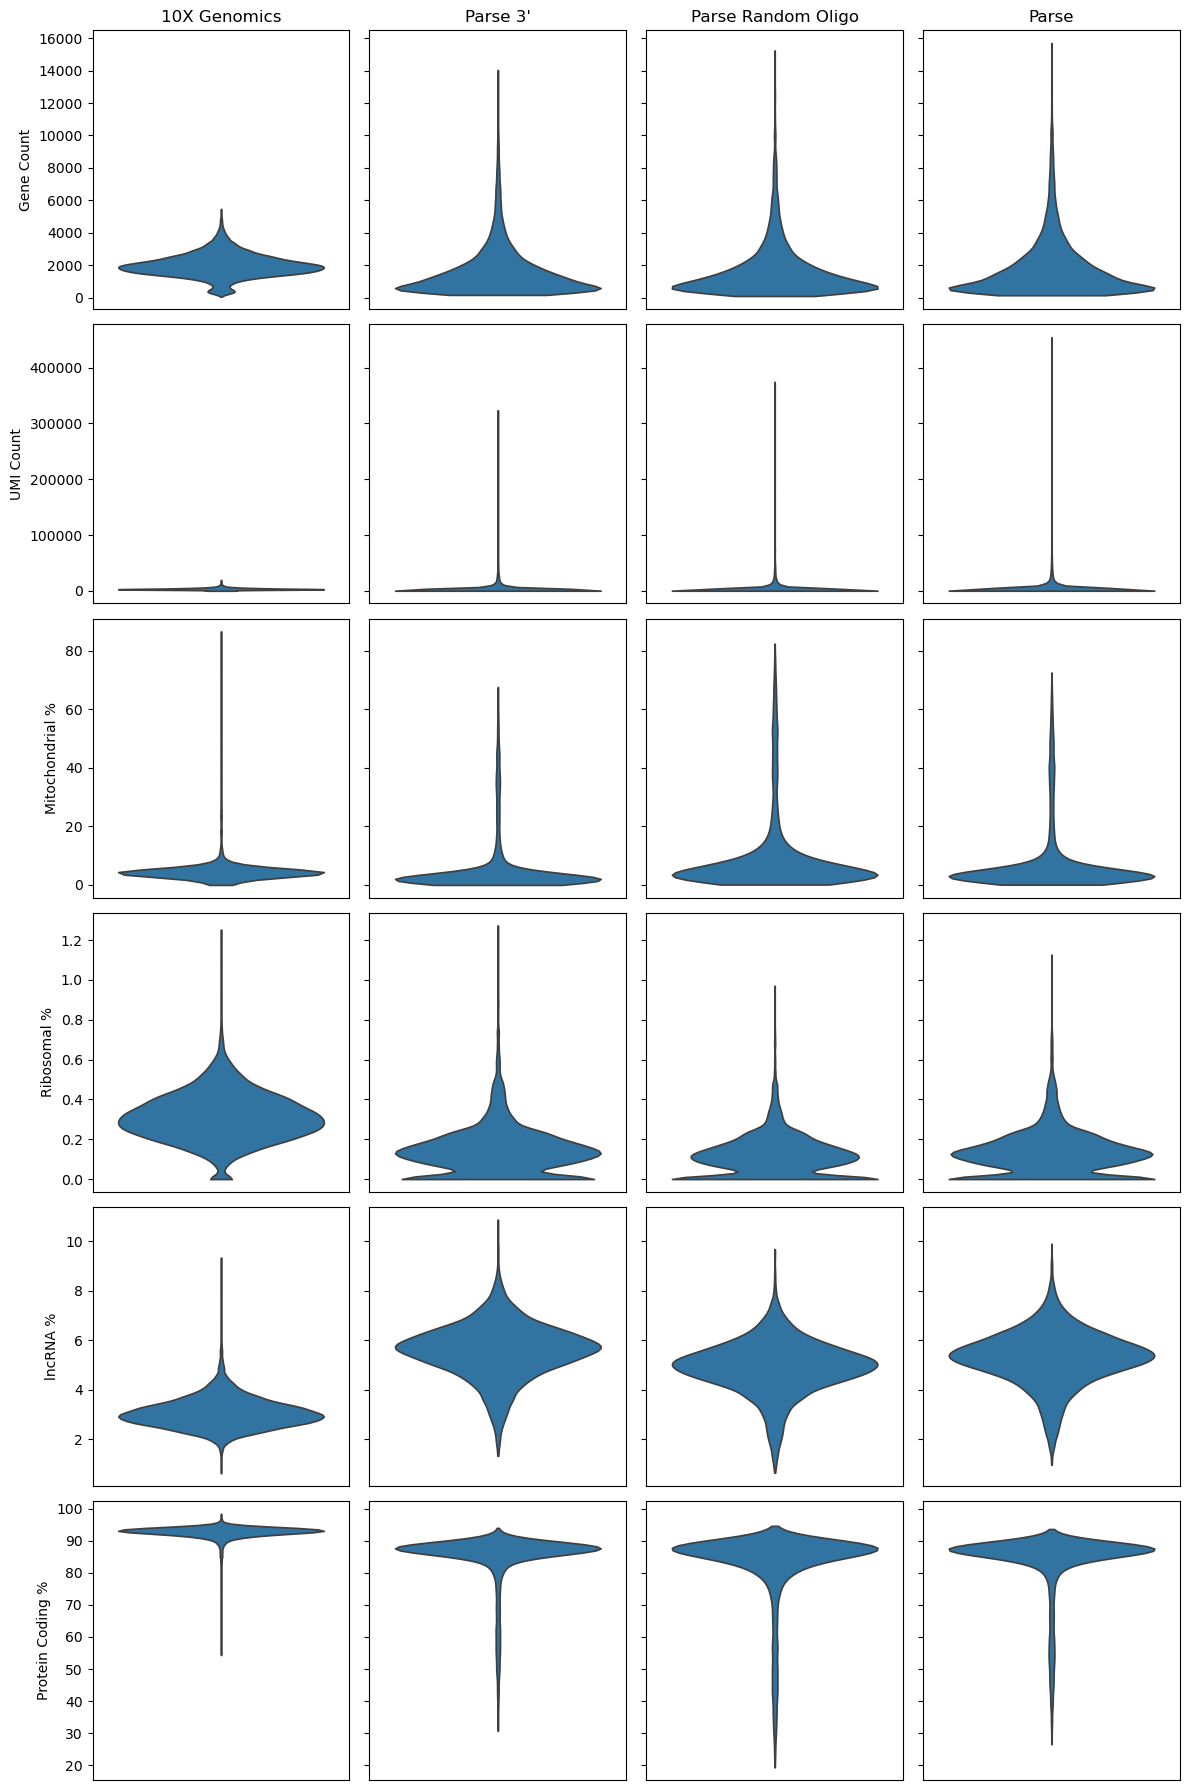

In [101]:
groups = ['n_genes', 'n_counts', 'percent_mito', 'percent_ribo', 'percent_lnc', 'percent_pc']
group_names = ['Gene Count', 'UMI Count', 'Mitochondrial %', 'Ribosomal %', 'lncRNA %', 'Protein Coding %']

plotting.plot_cell_metrics(datasets, groups=groups, group_names=group_names, figsize=(12,18))

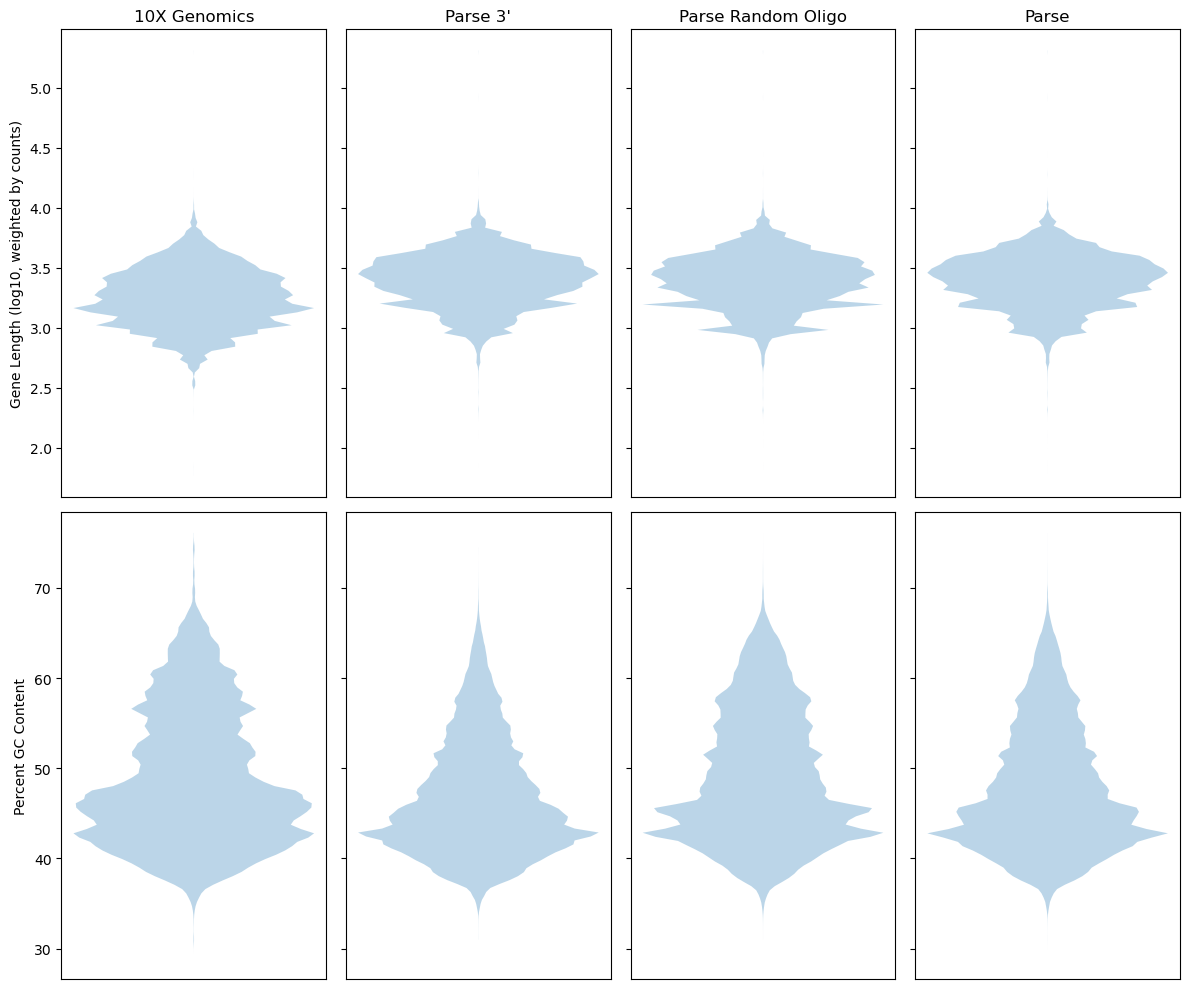

In [102]:
plotting.plot_gene_metrics(datasets, sample_size = 1000000)

# Read/Gene Comparisons

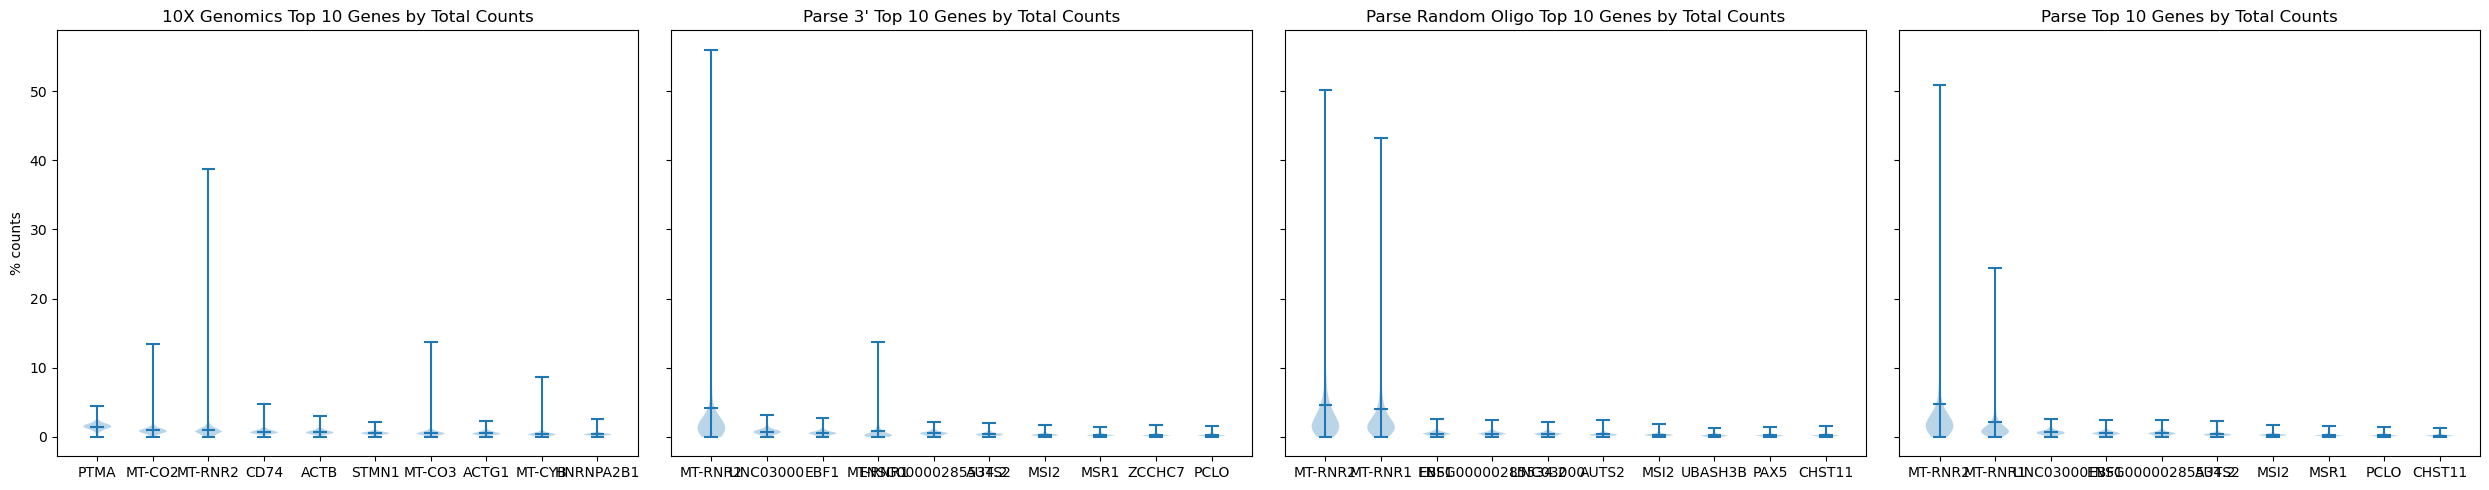

In [103]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)

for i, data in enumerate(datasets):
    plotting.top_gene_counts(ax[i], data)

ax[0].set_ylabel("% counts")

plt.tight_layout()
plt.show()

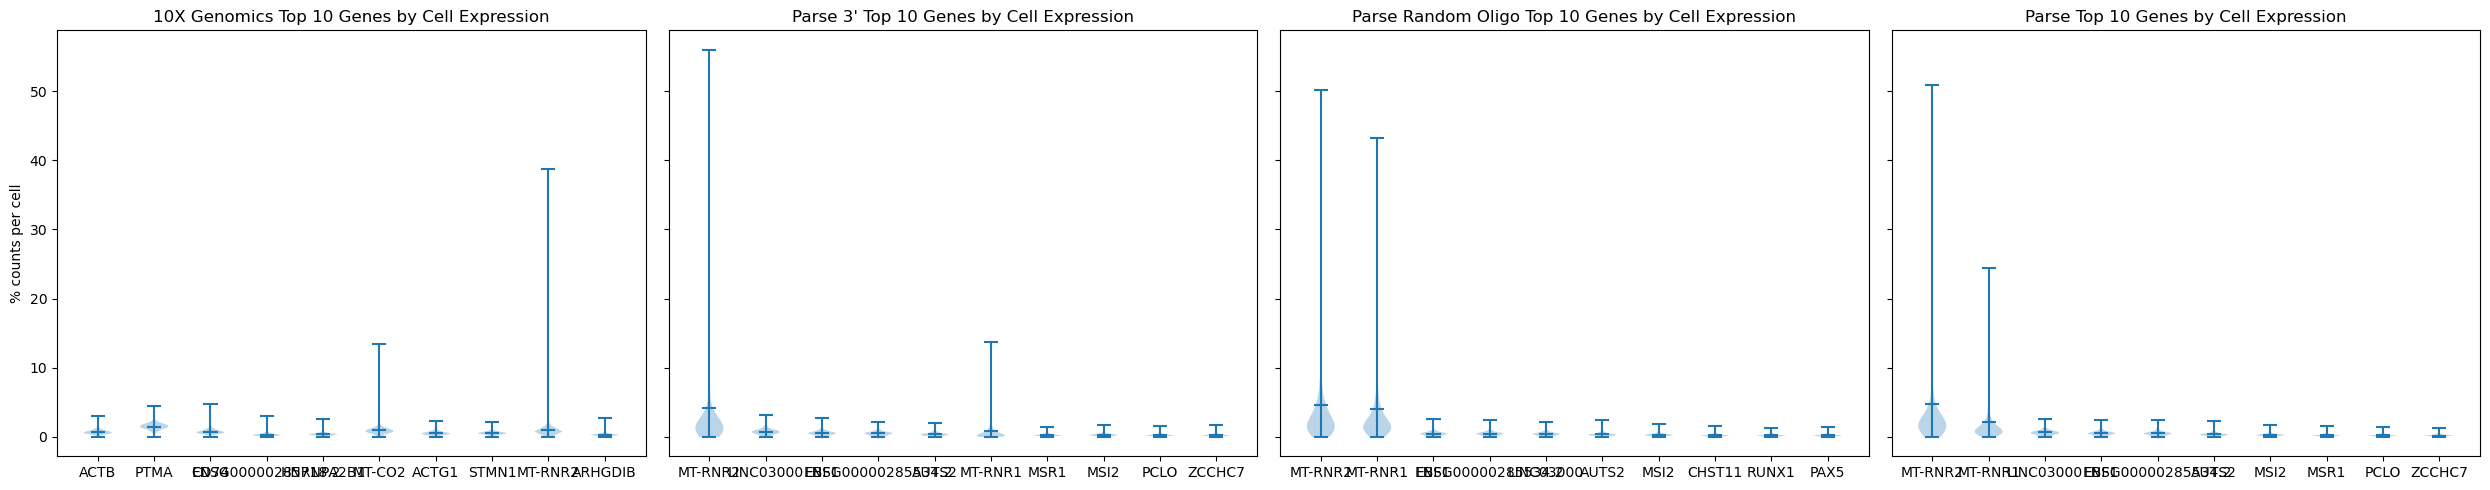

In [104]:
fig, ax = plt.subplots(1, 4, figsize=(25,5), sharey=True)
for i, data in enumerate(datasets):
    plotting.top_gene_cell_expression(ax[i], data)

ax[0].set_ylabel("% counts per cell")

plt.tight_layout()
plt.show()

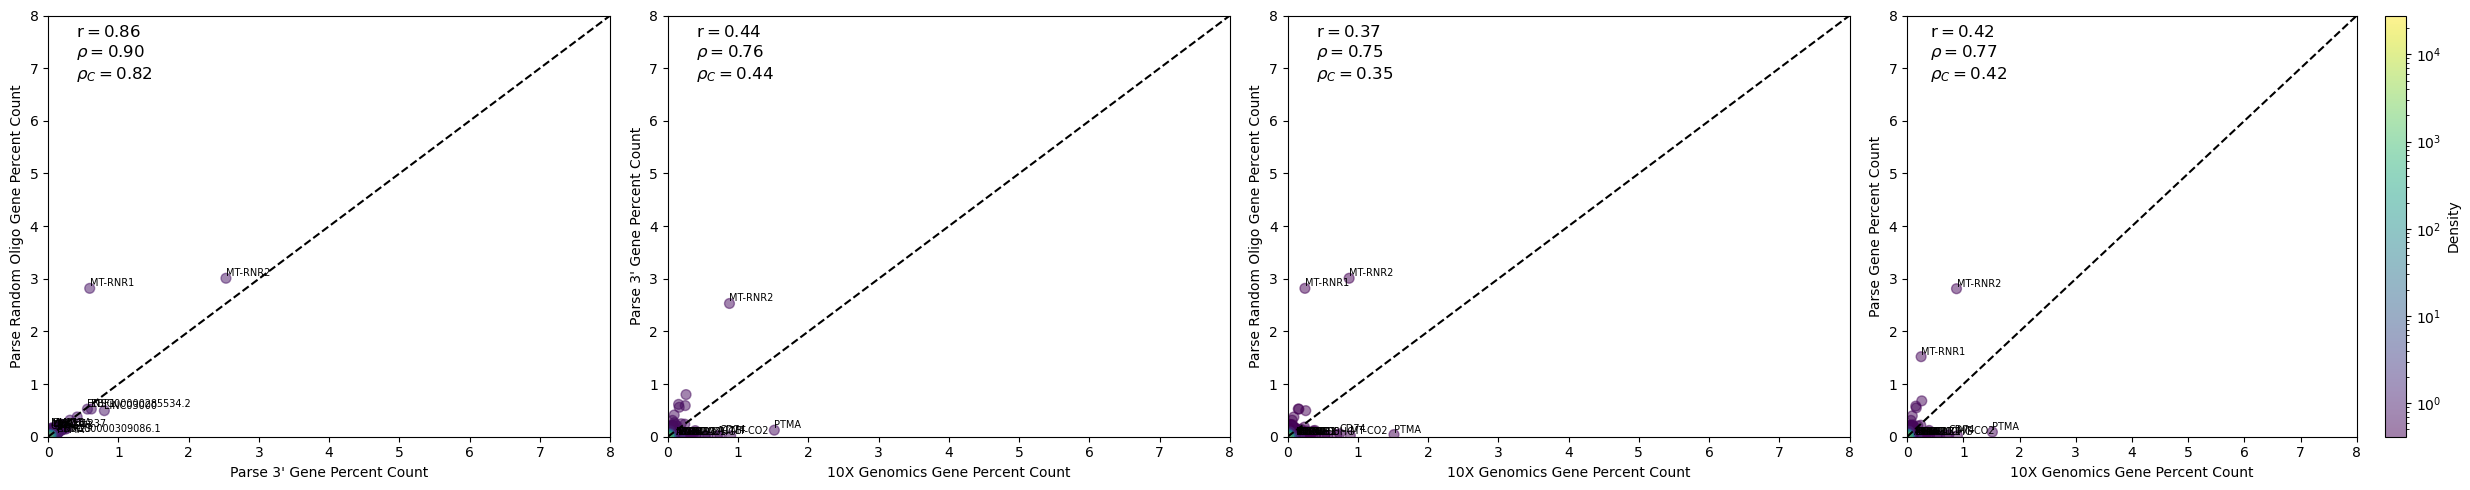

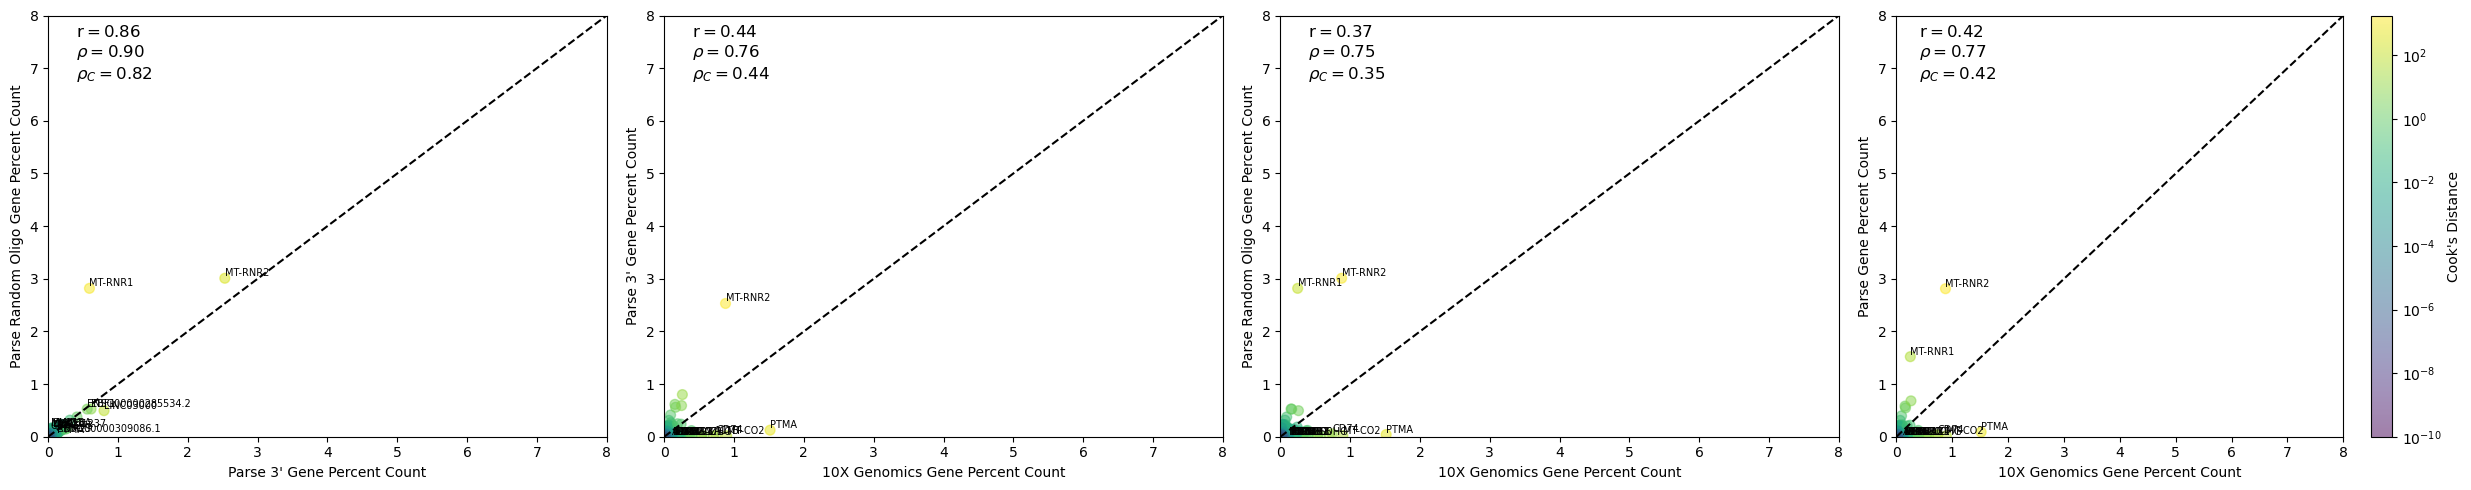

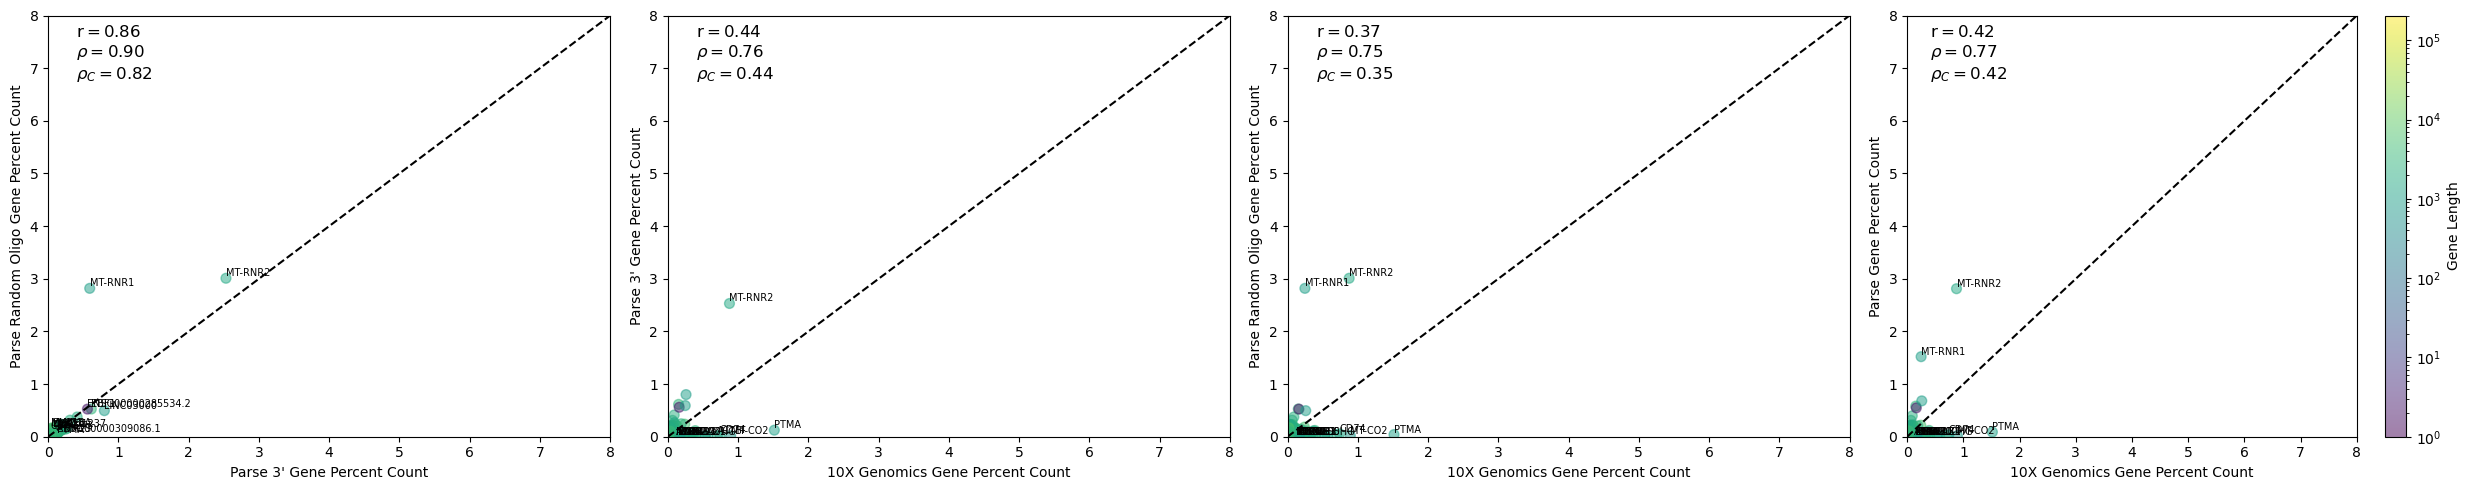

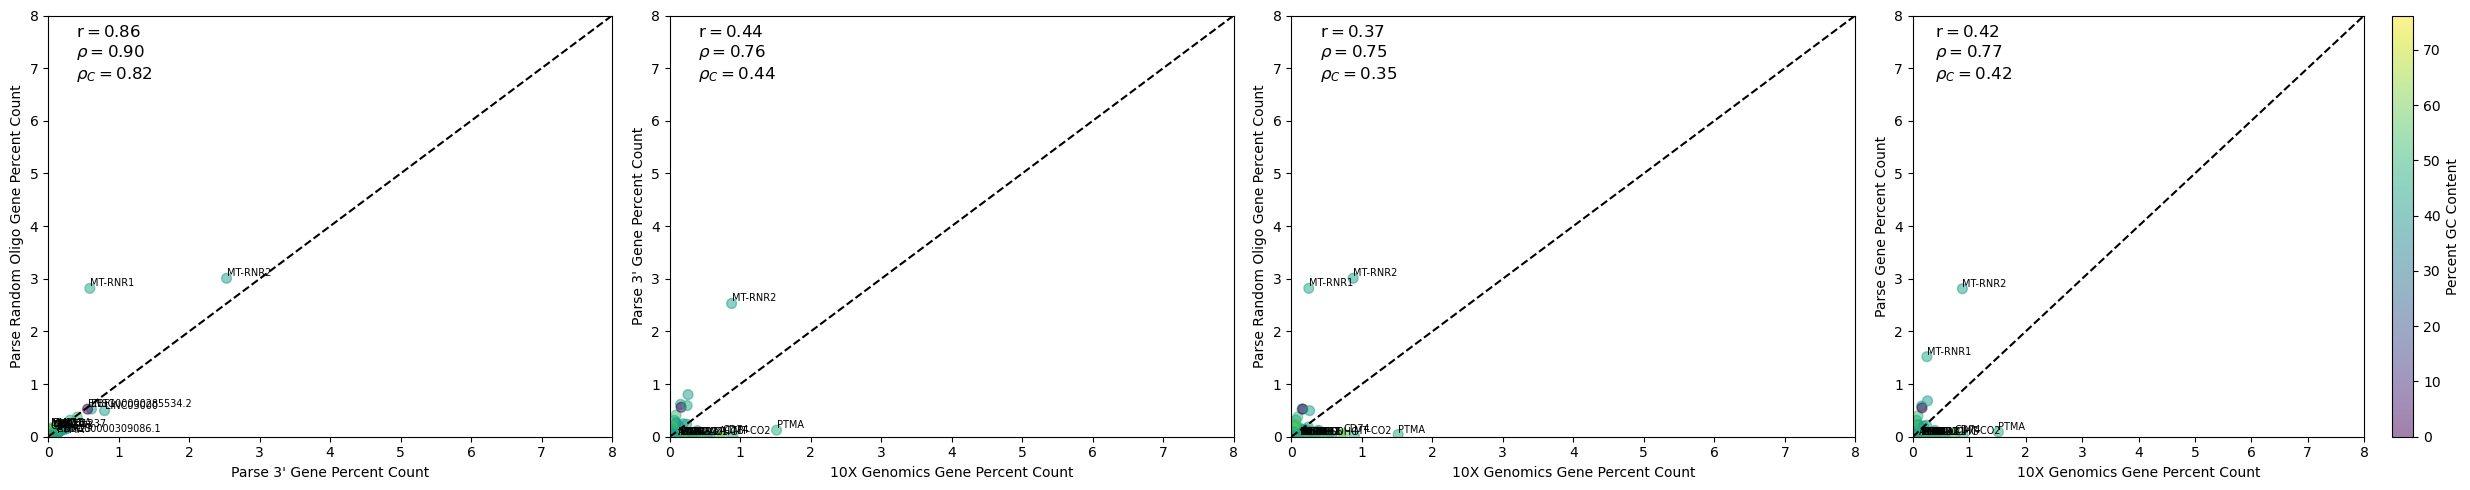

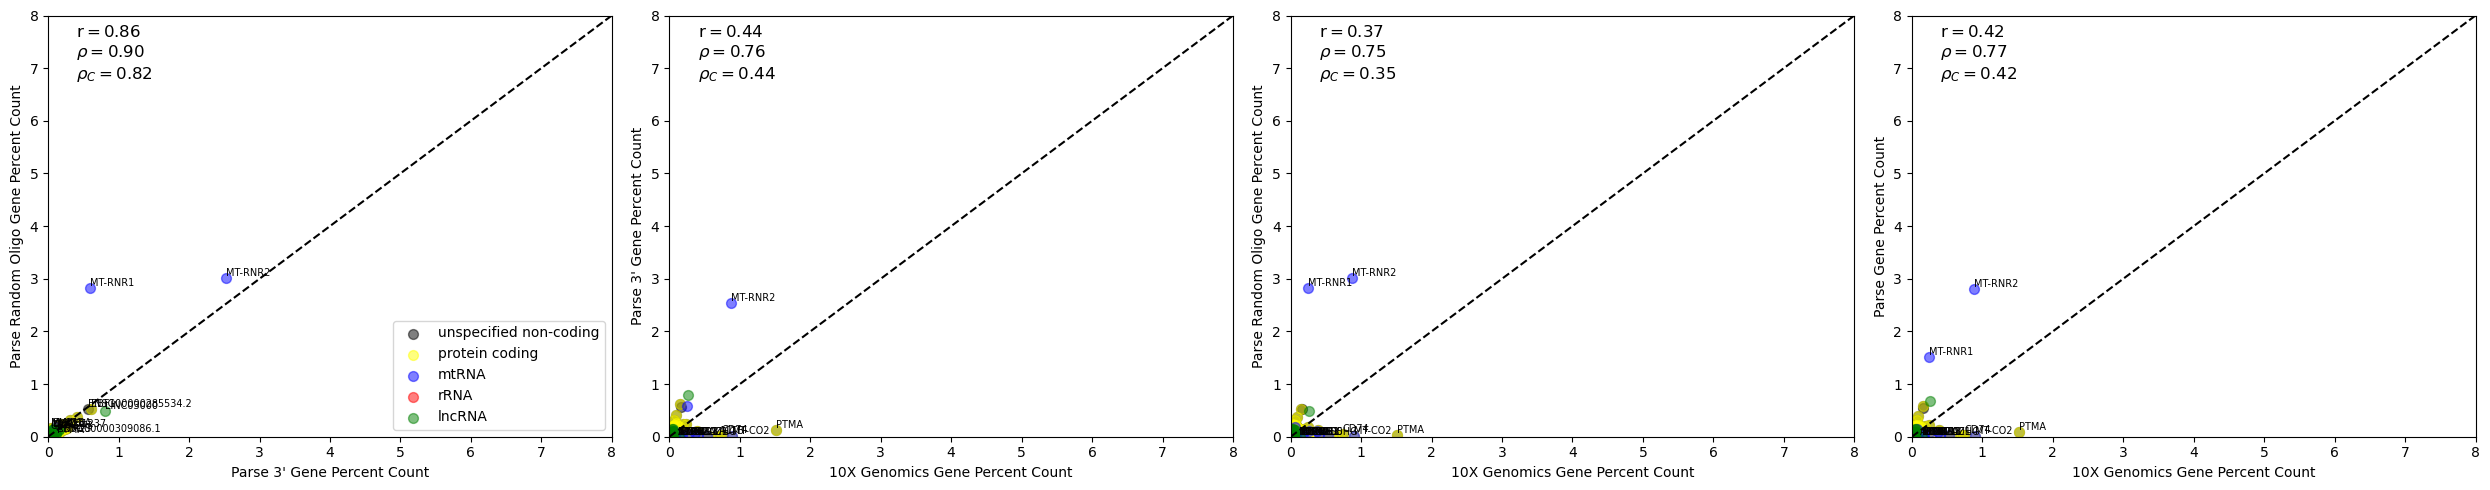

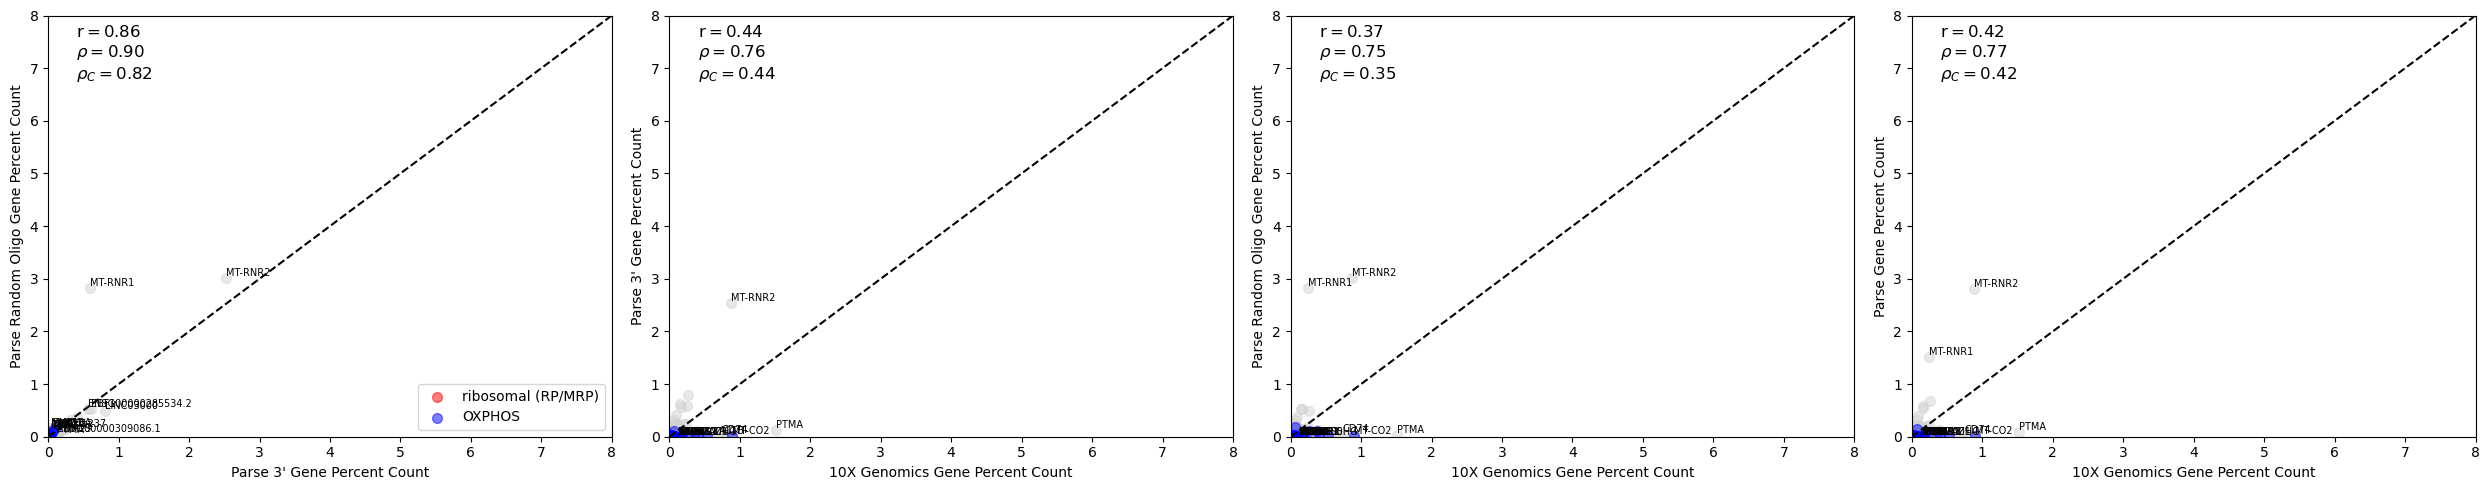

In [105]:
compare_names, compare_dfs = plotting.compare(datasets, 8)

/home/mcaskey/10XvParse/XvP_utils/plotting/combo_plots.py:717: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


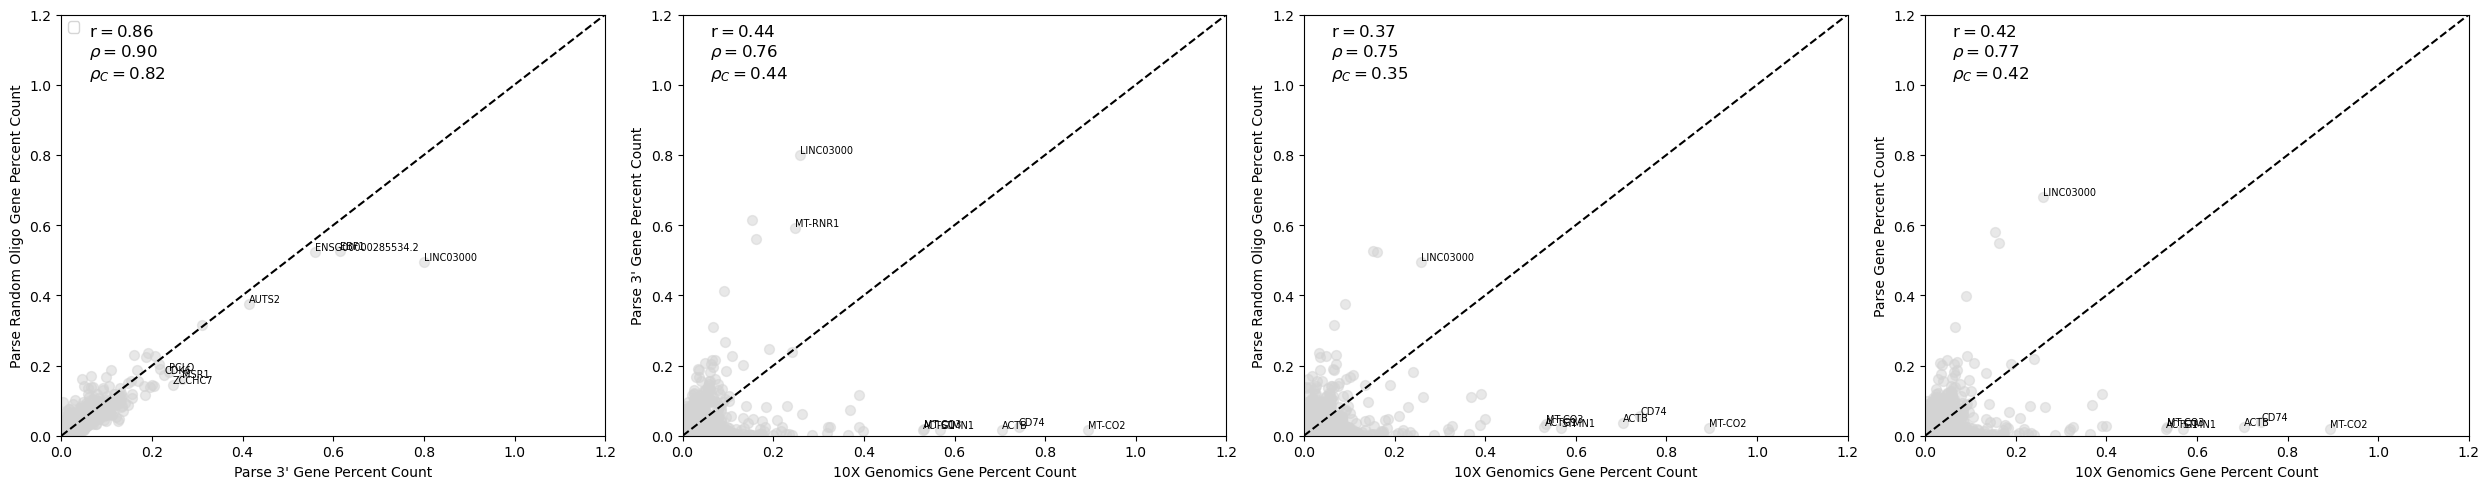

In [108]:
data_10x = datasets[0]
data_polyT = datasets[1]
data_randO = datasets[2]
data_parse = datasets[3]

comparisons = [(data_polyT, data_randO),
                (data_10x, data_polyT),
                (data_10x, data_randO),
                (data_10x, data_parse)]

plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=1.2,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2023"],
    terms=["Translation (GO:0006412)"],n_log_ratio=0
)

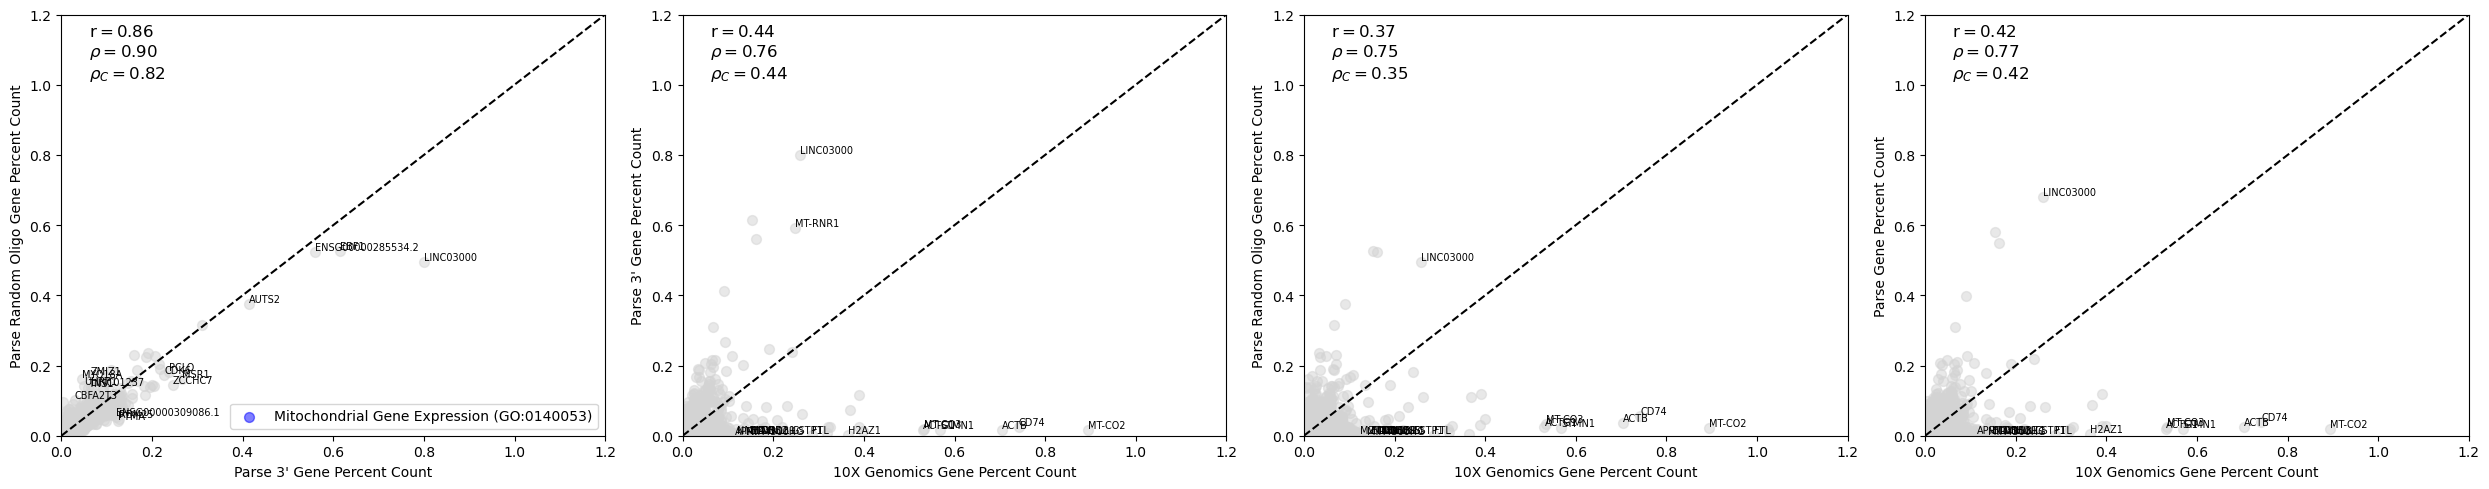

In [107]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=1.2,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2023"],
    terms=["Mitochondrial Gene Expression (GO:0140053)"])

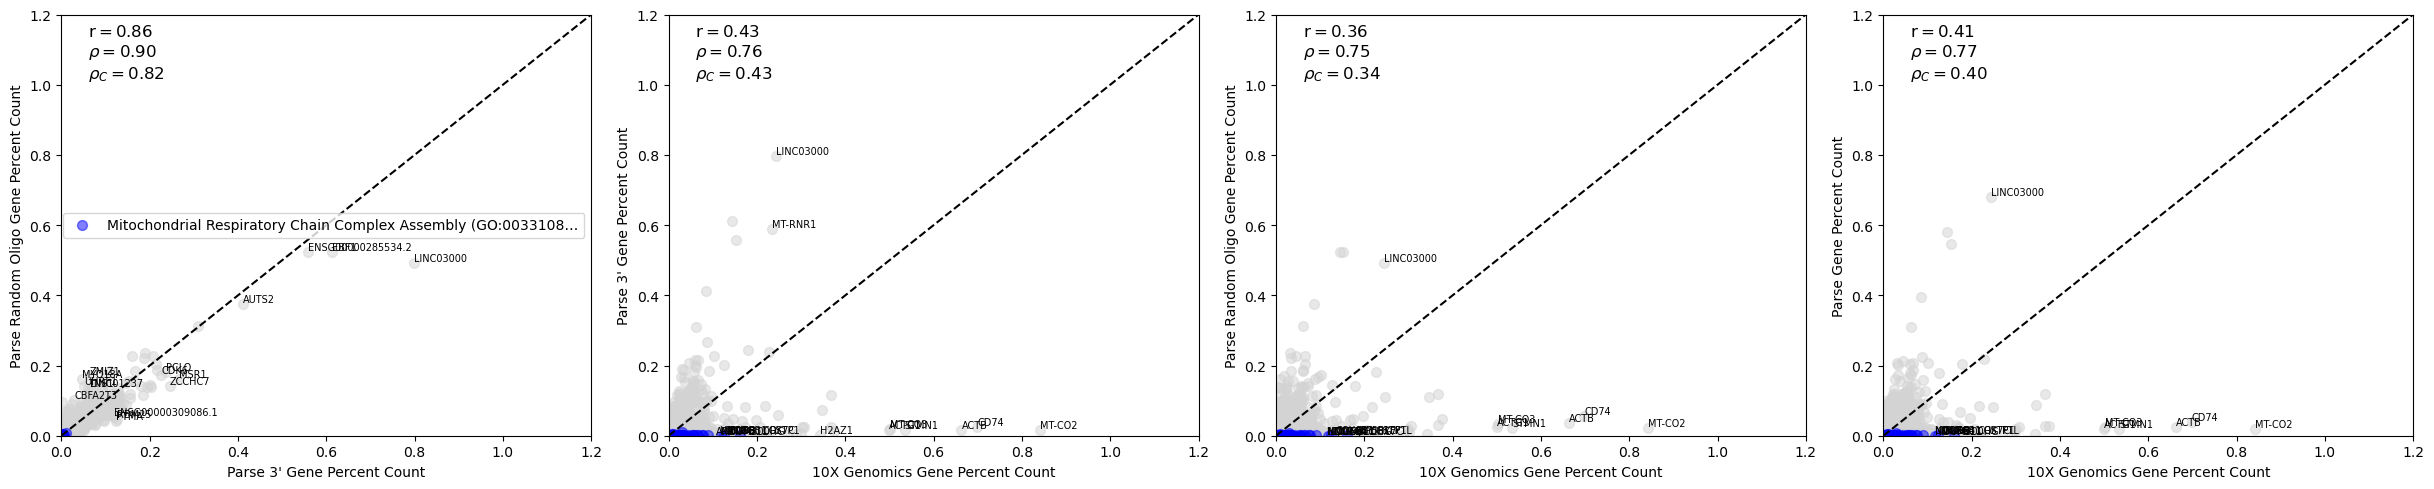

In [79]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=1.2,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2023"],
    terms=["Mitochondrial Respiratory Chain Complex Assembly (GO:0033108)"])

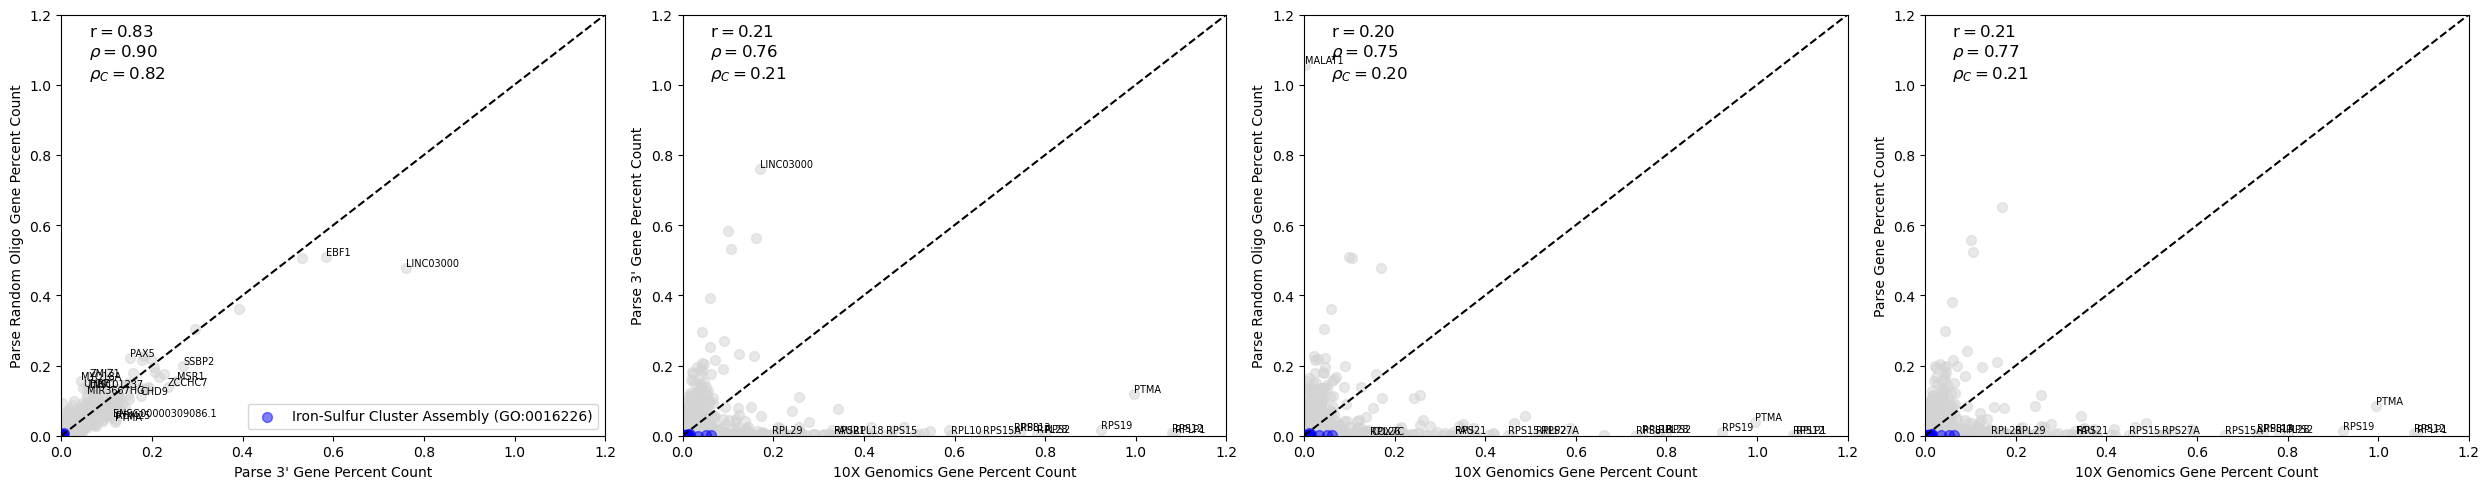

In [27]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=1.2,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2023"],
    terms=["Iron-Sulfur Cluster Assembly (GO:0016226)"])

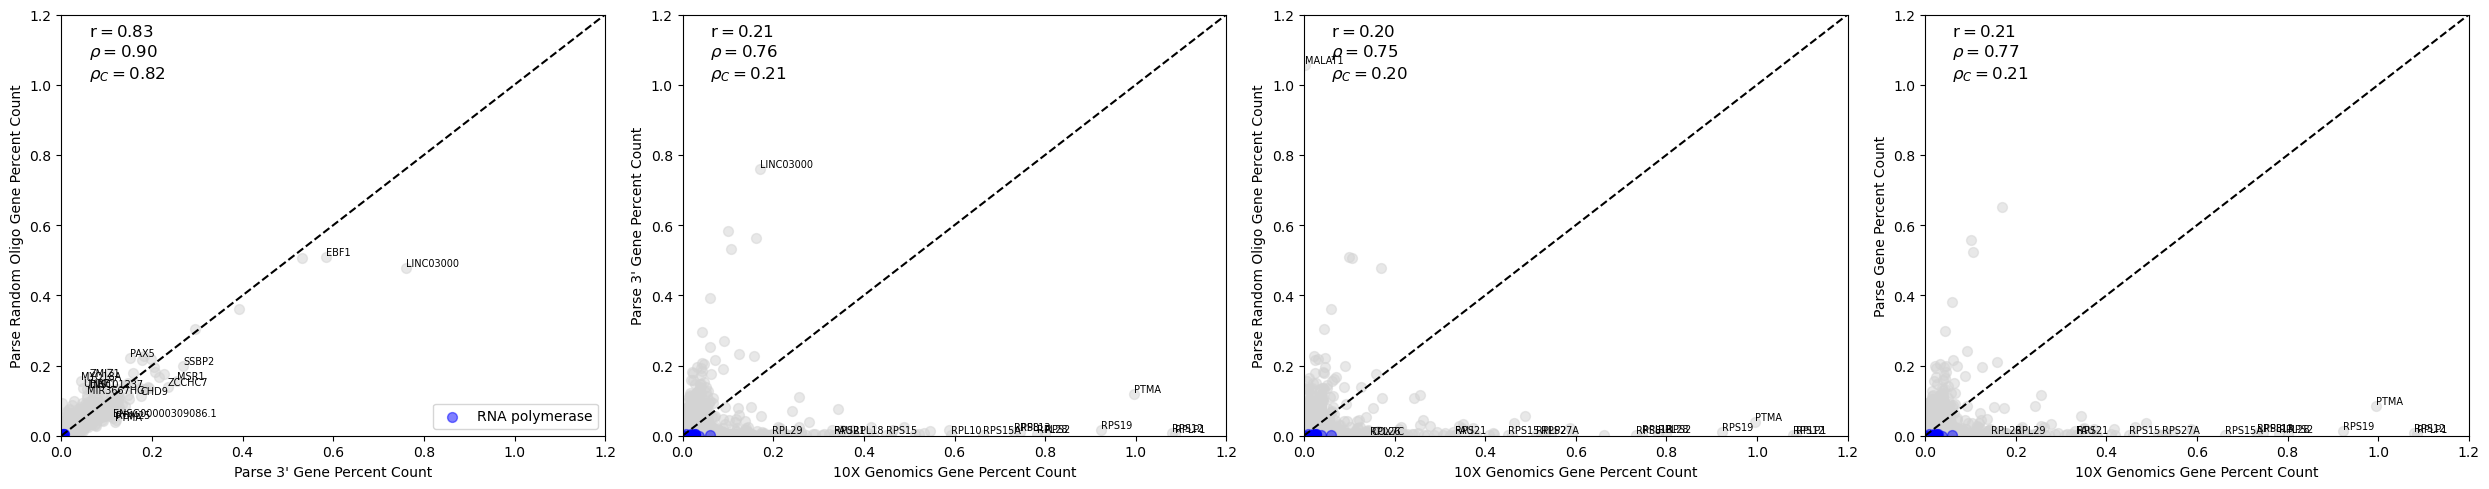

In [29]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=1.2,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["KEGG_2021_Human"],
    terms=["RNA polymerase"])

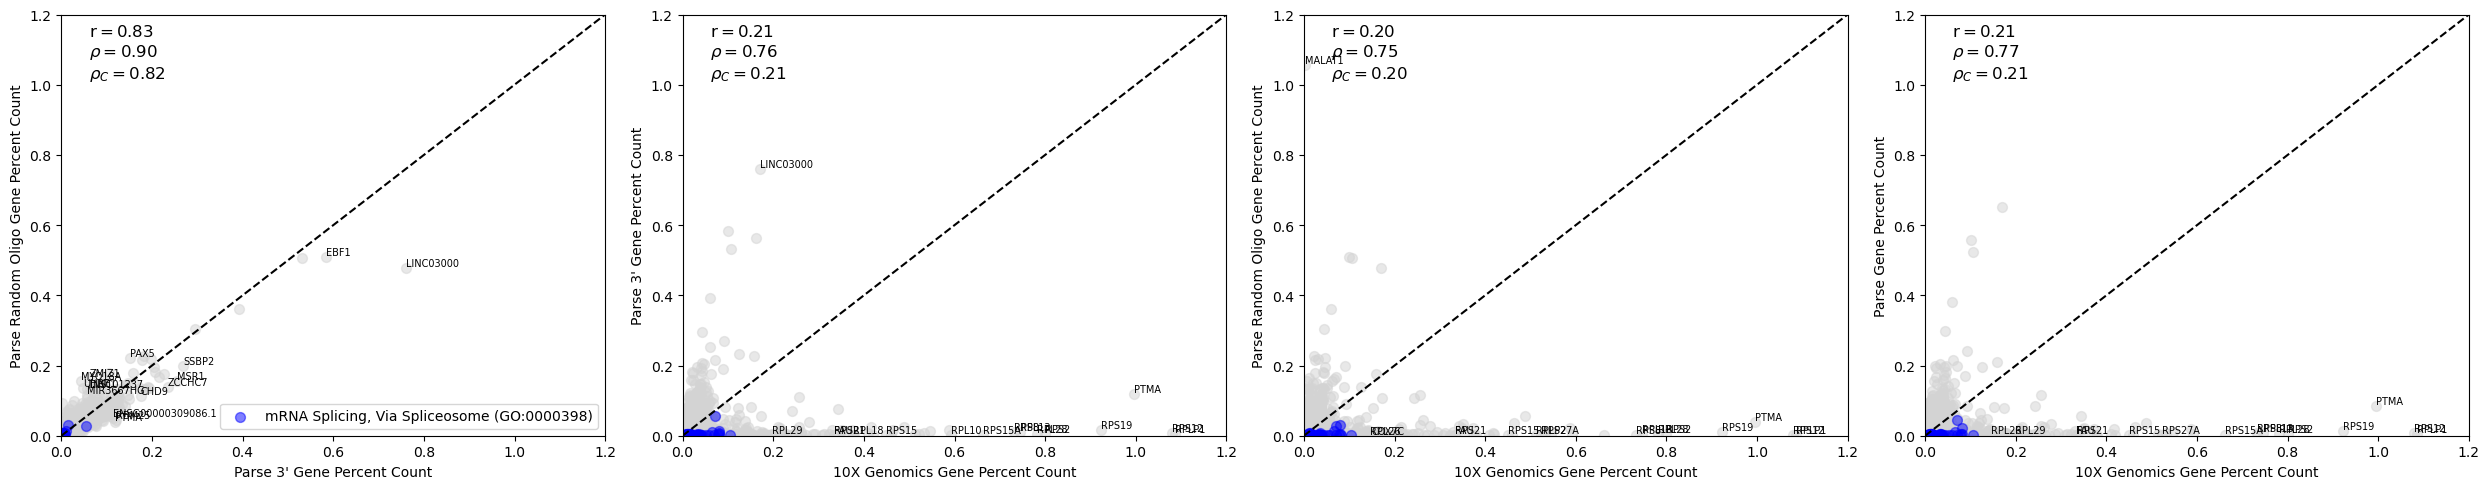

In [38]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=1.2,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2023"],
    terms=["mRNA Splicing, Via Spliceosome (GO:0000398)"])

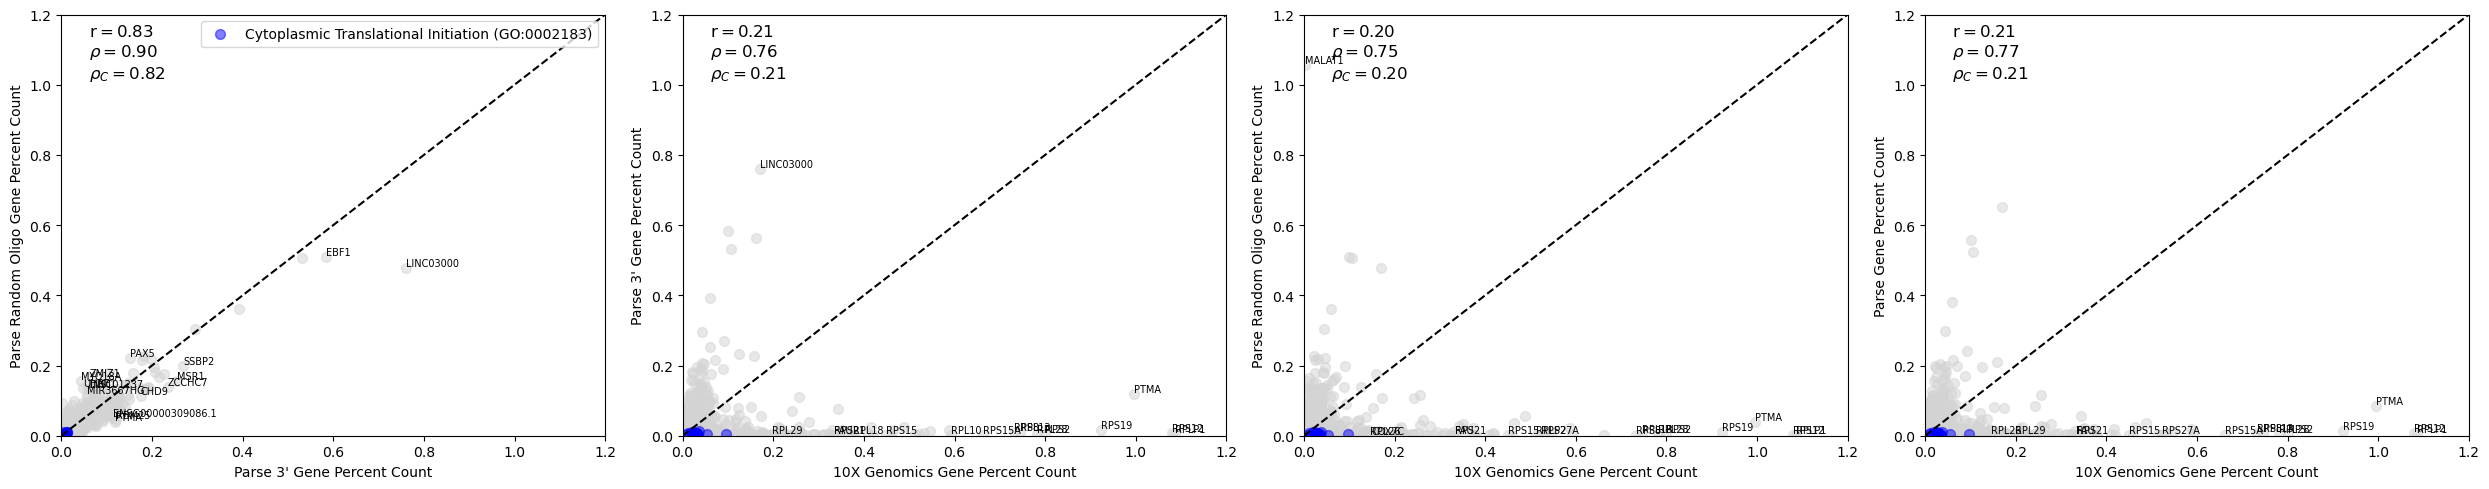

In [42]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=1.2,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2023"],
    terms=["Cytoplasmic Translational Initiation (GO:0002183)"])

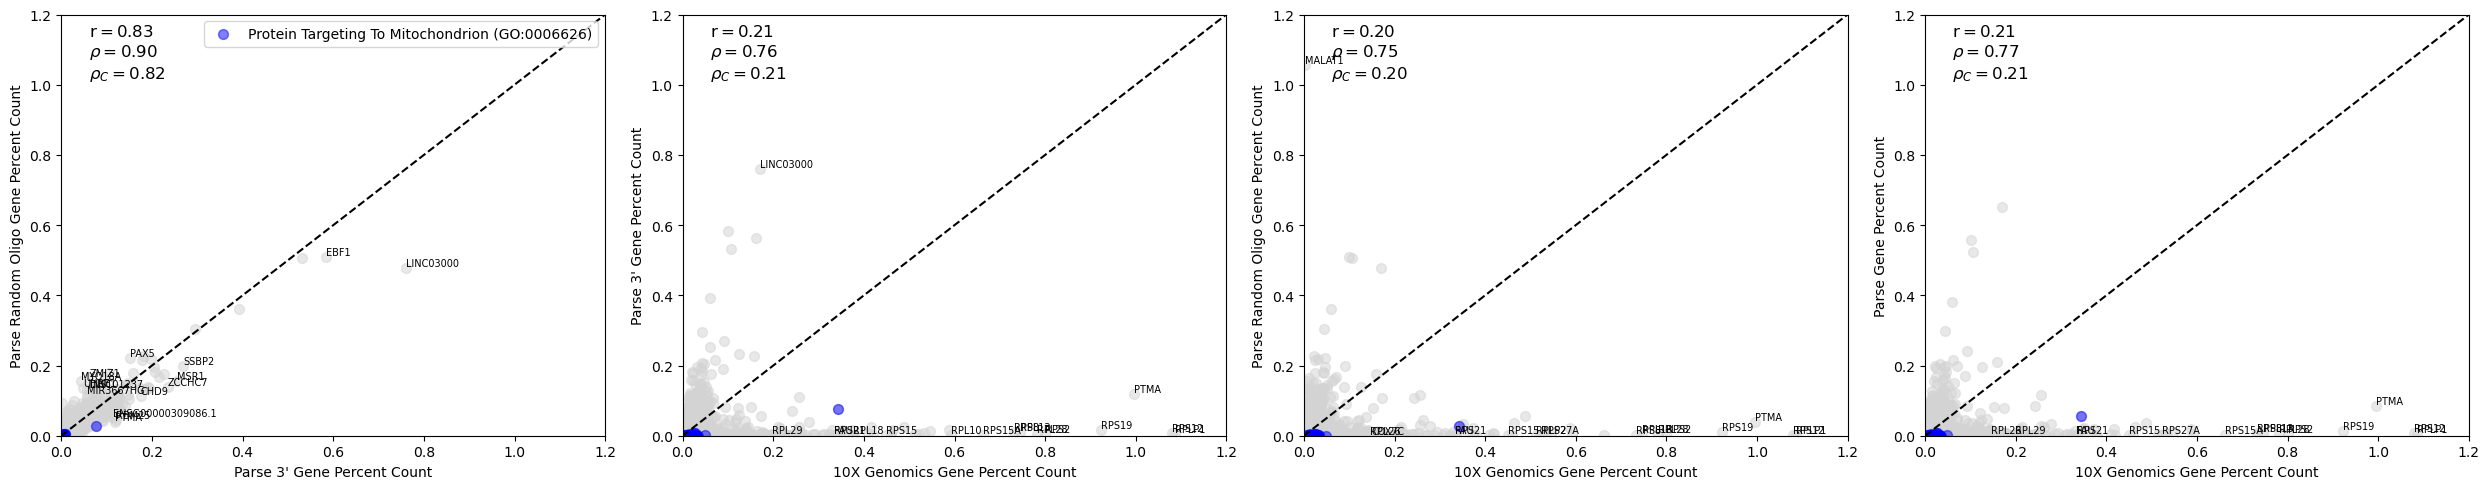

In [39]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=1.2,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["GO_Biological_Process_2023"],
    terms=["Protein Targeting To Mitochondrion (GO:0006626)", "GO BP: Protein Targeting To ER (GO:0045047)"])

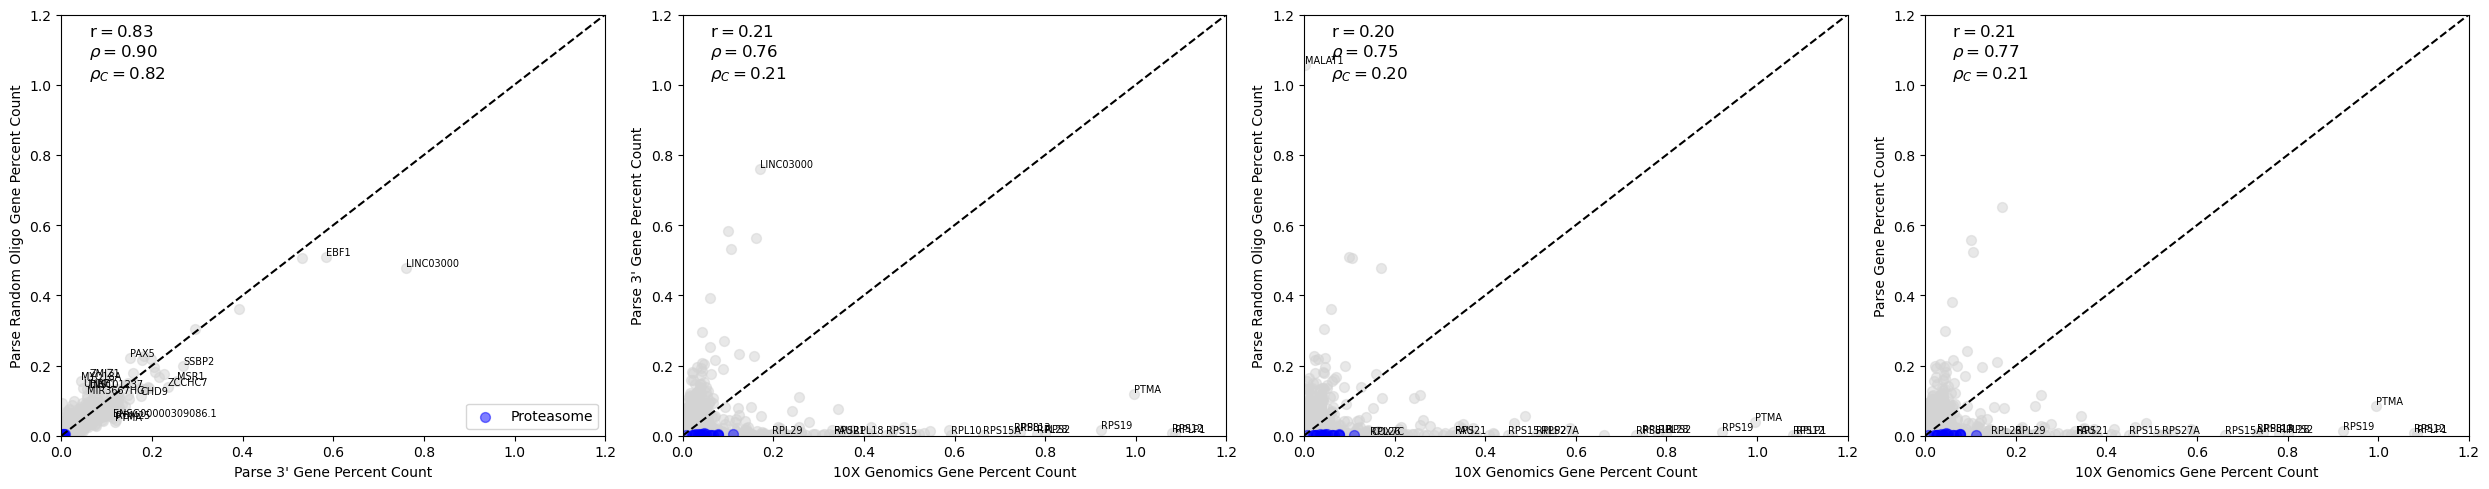

In [40]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=1.2,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["KEGG_2021_Human"],
    terms=["Proteasome"])

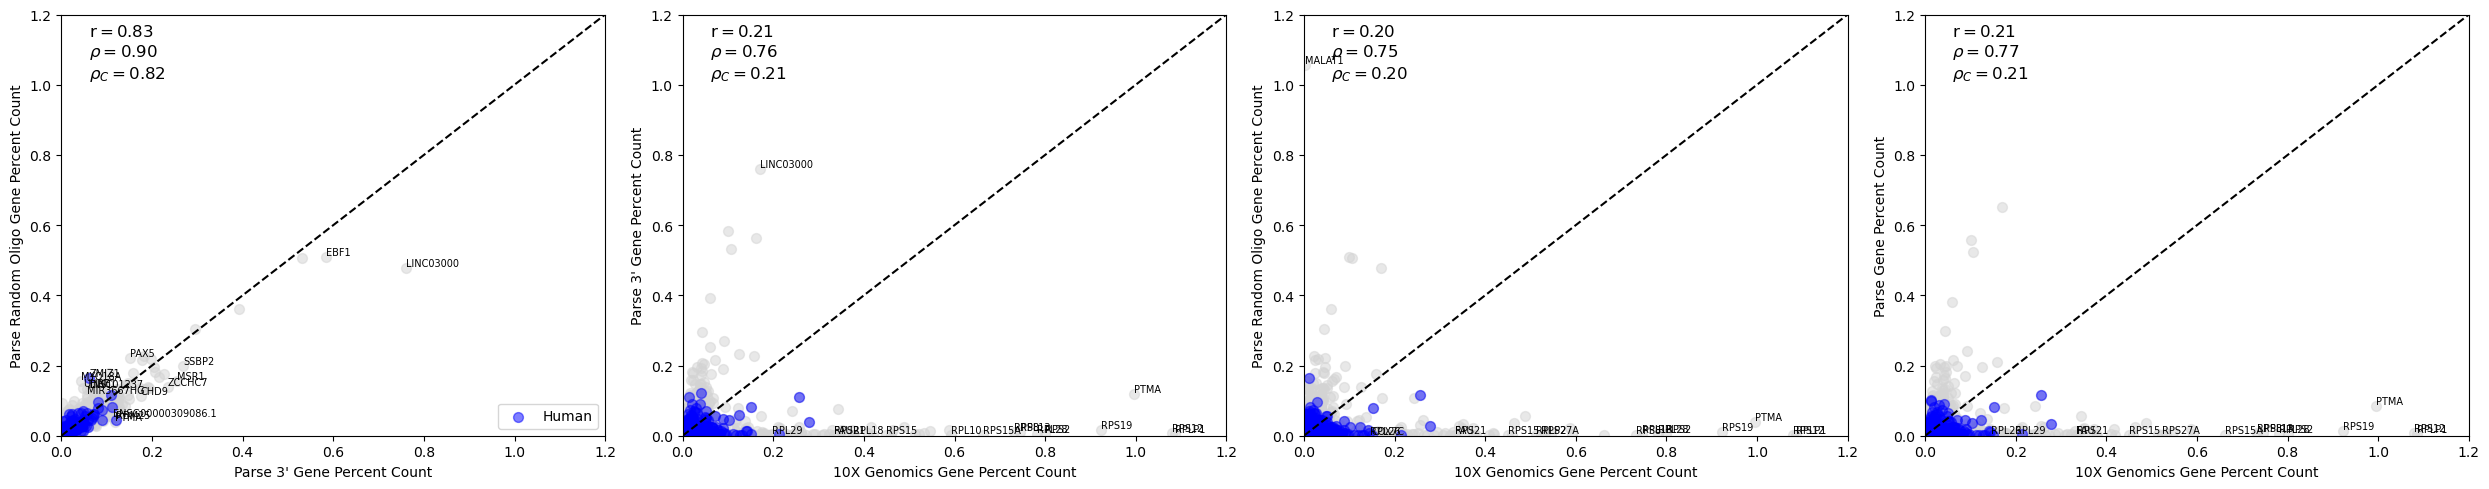

In [35]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=1.2,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/housekeeping_genes.csv",
    gene_sets=["Housekeeping"],
    terms=["Human"])

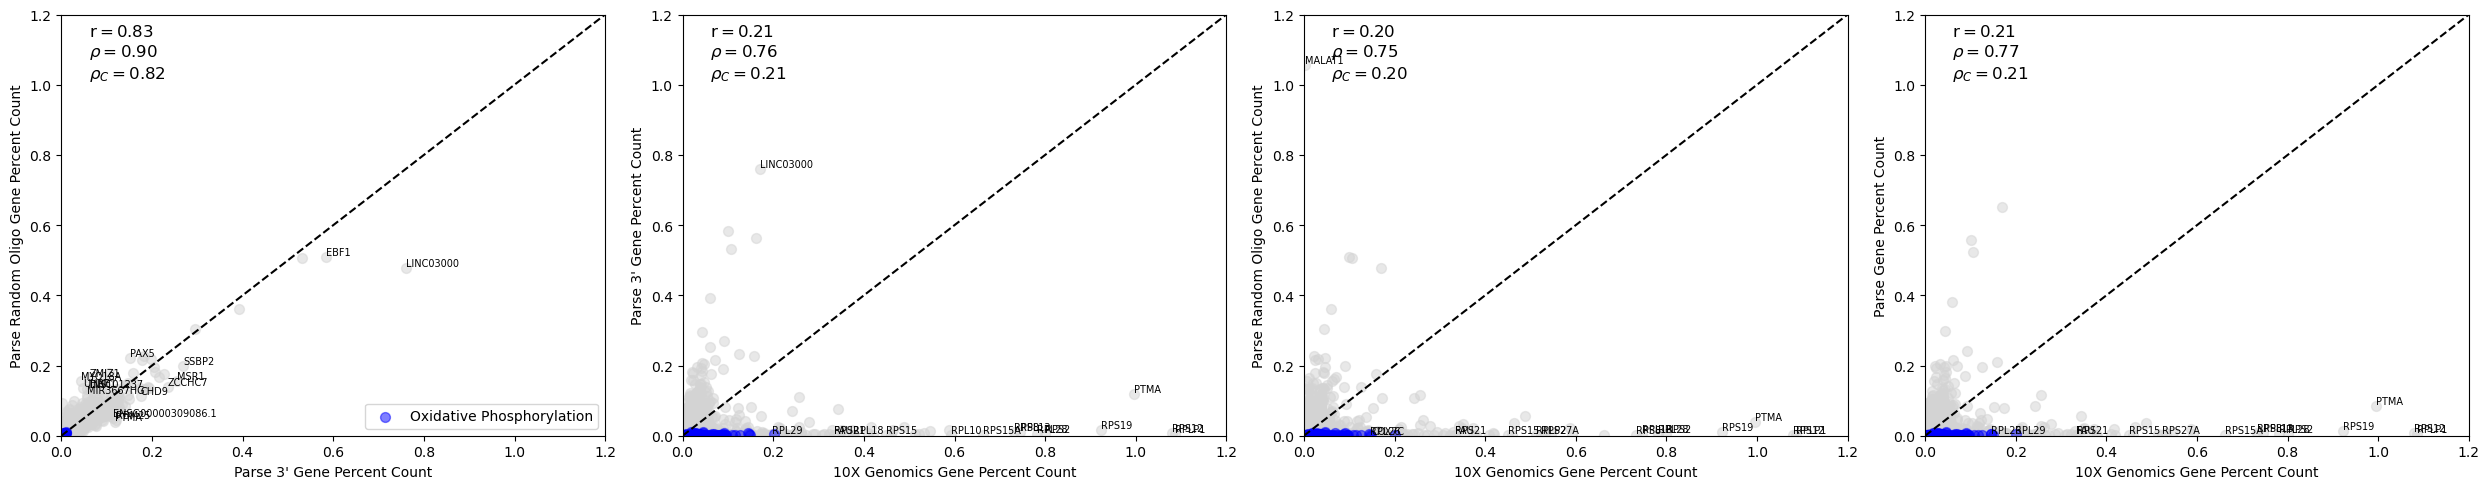

In [42]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=1.2,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["MSigDB_Hallmark_2020"],
    terms=["Oxidative Phosphorylation"]
)

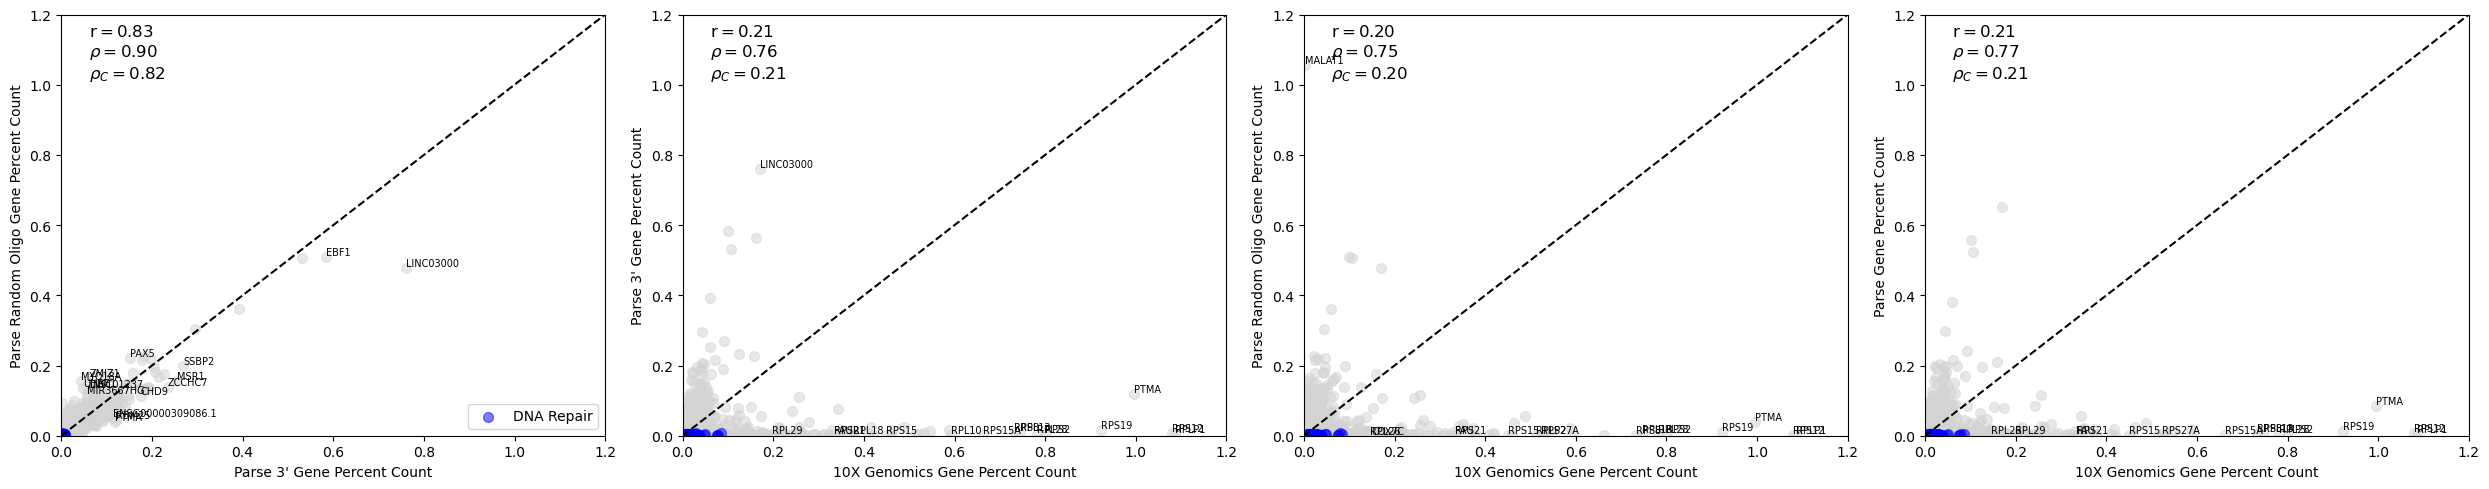

In [43]:
plotting.compare_by_enrichment(
    compare_dfs, comparisons, lim=1.2,
    enrichment_path="/home/mcaskey/10XvParse/Notebooks/Comparisons/10XvParse/10x_outliers/enrichment_results.csv",
    gene_sets=["MSigDB_Hallmark_2020"],
    terms=["DNA Repair"]
)

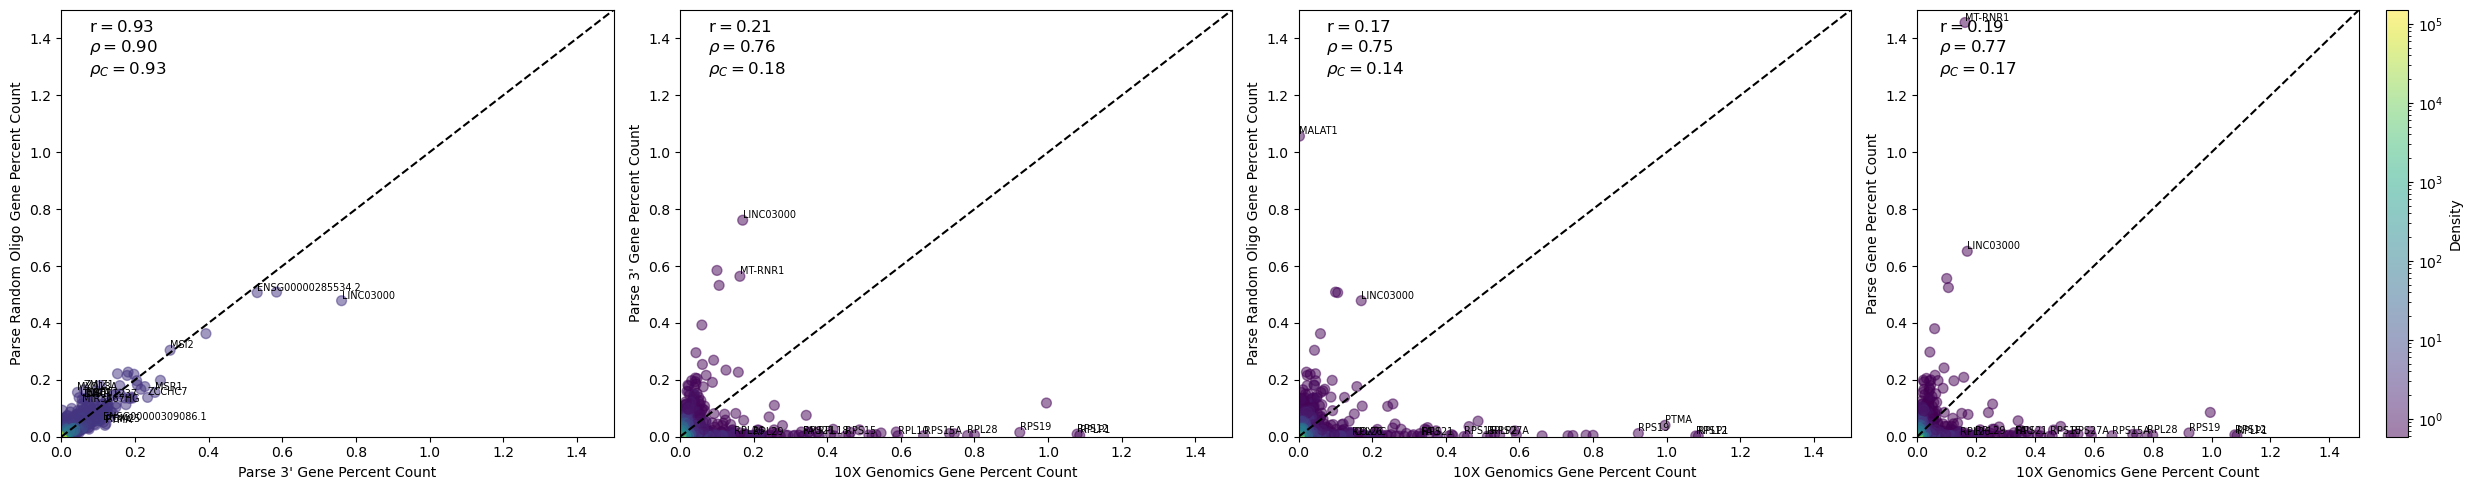

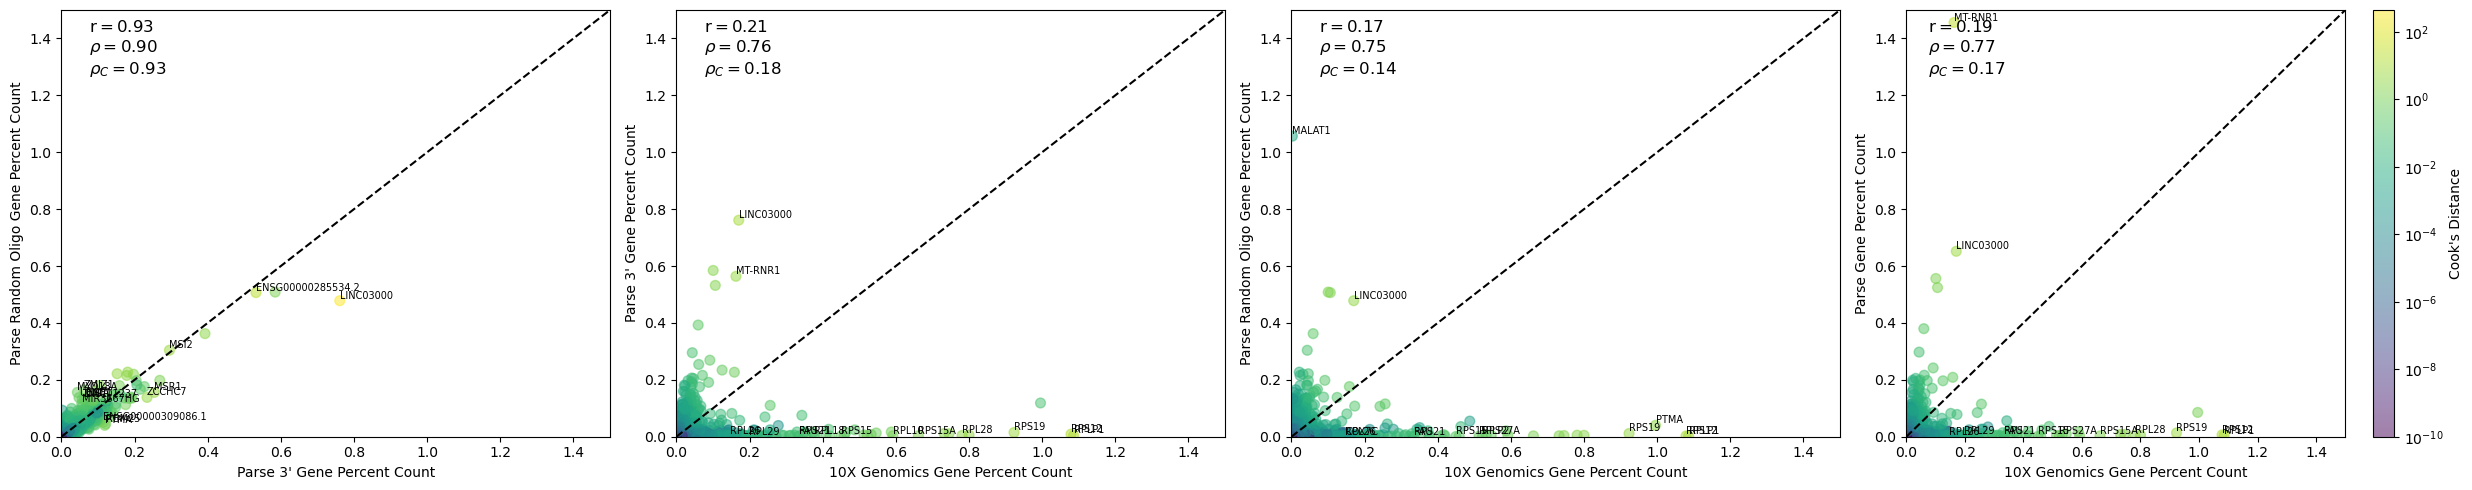

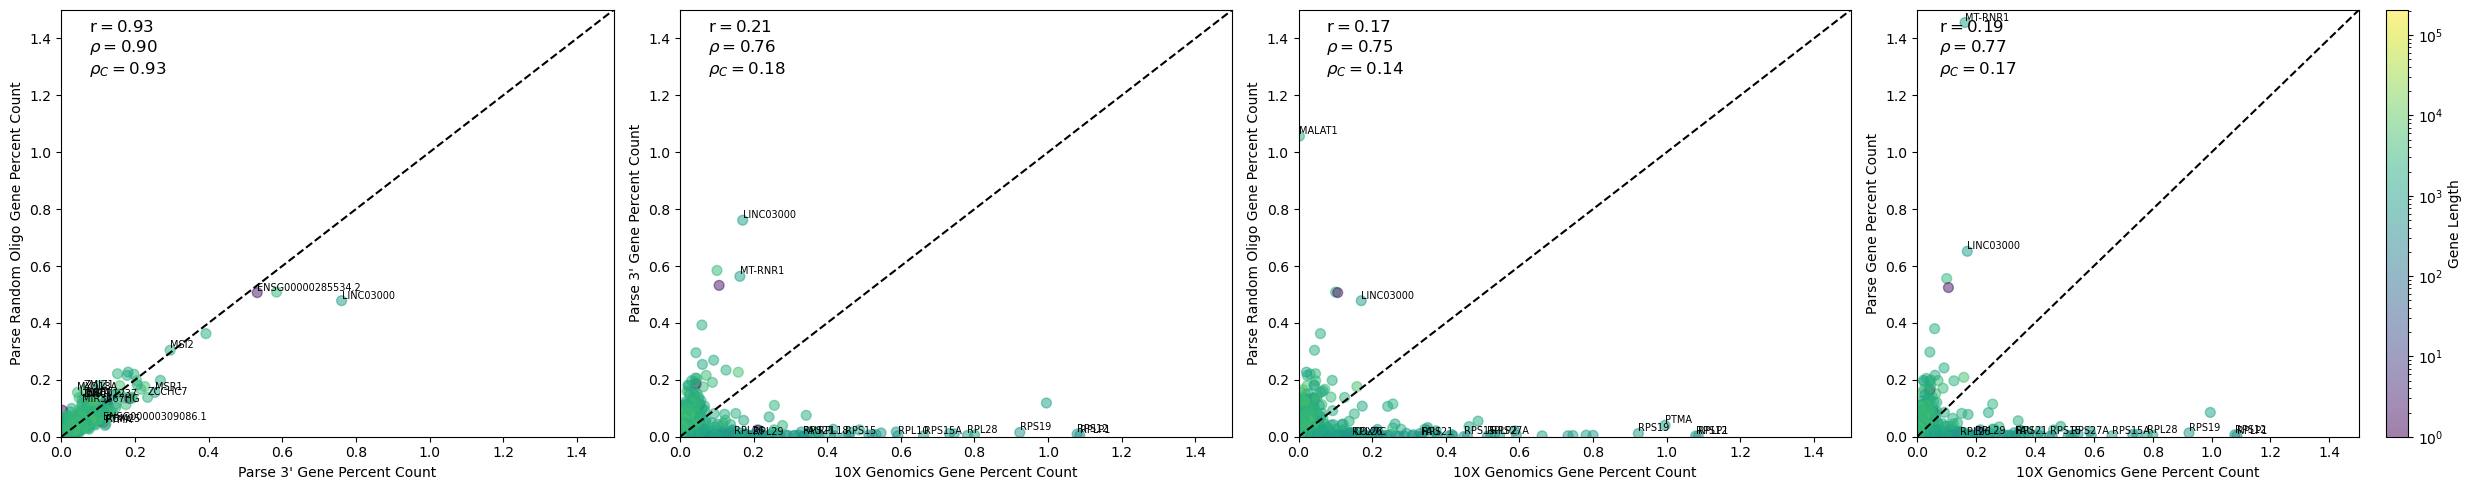

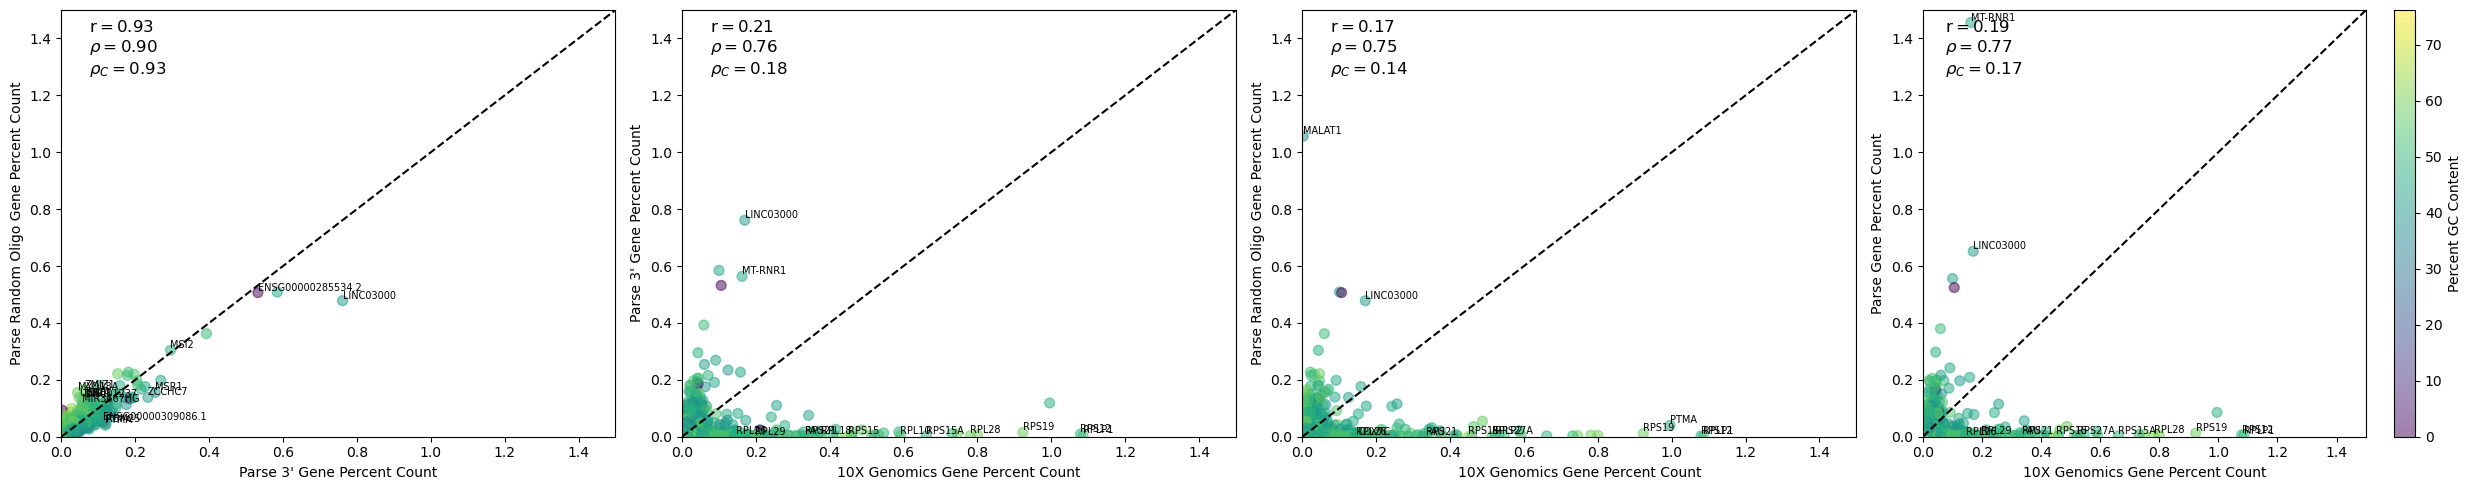

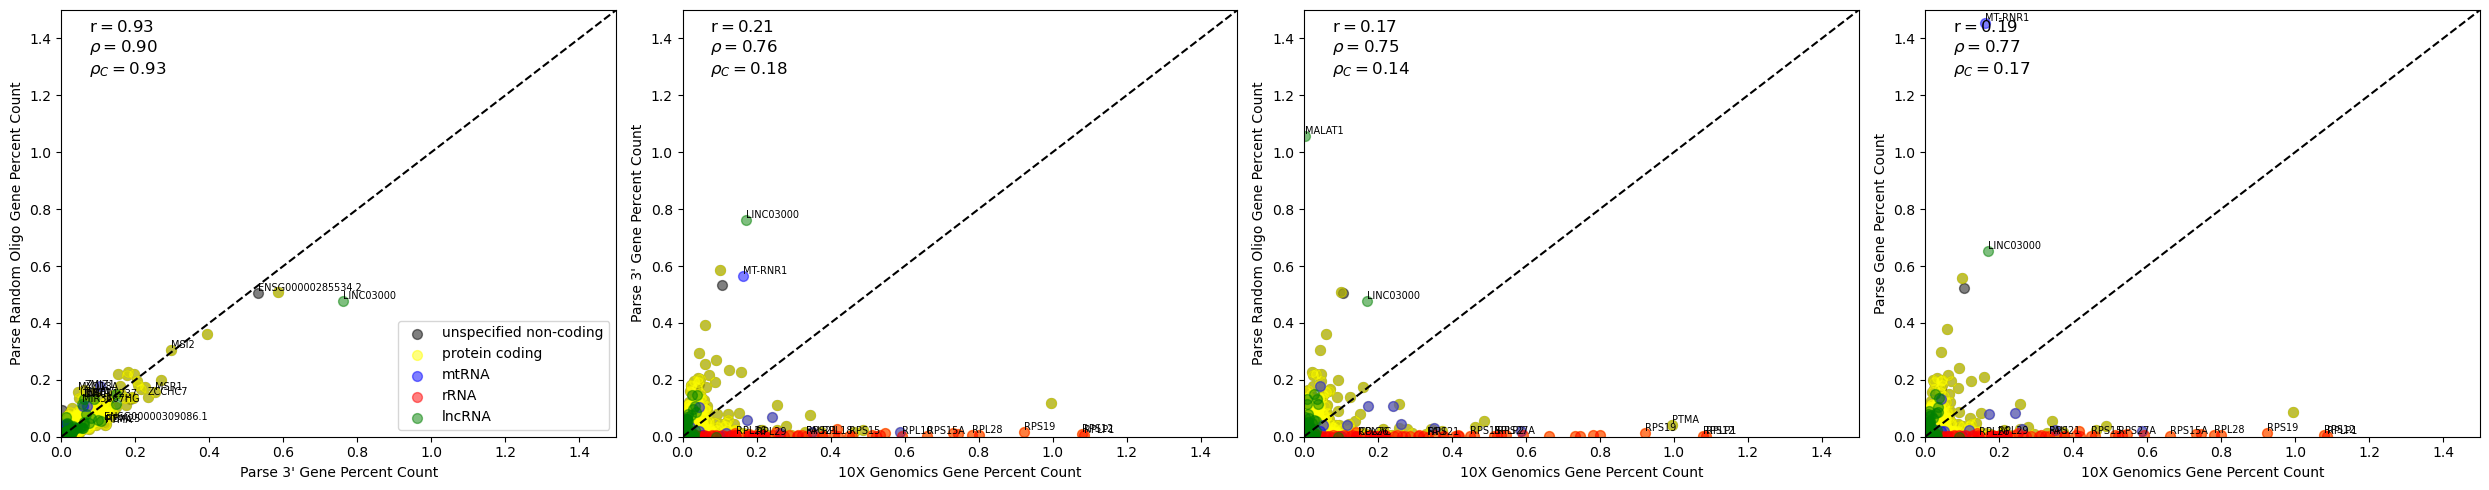

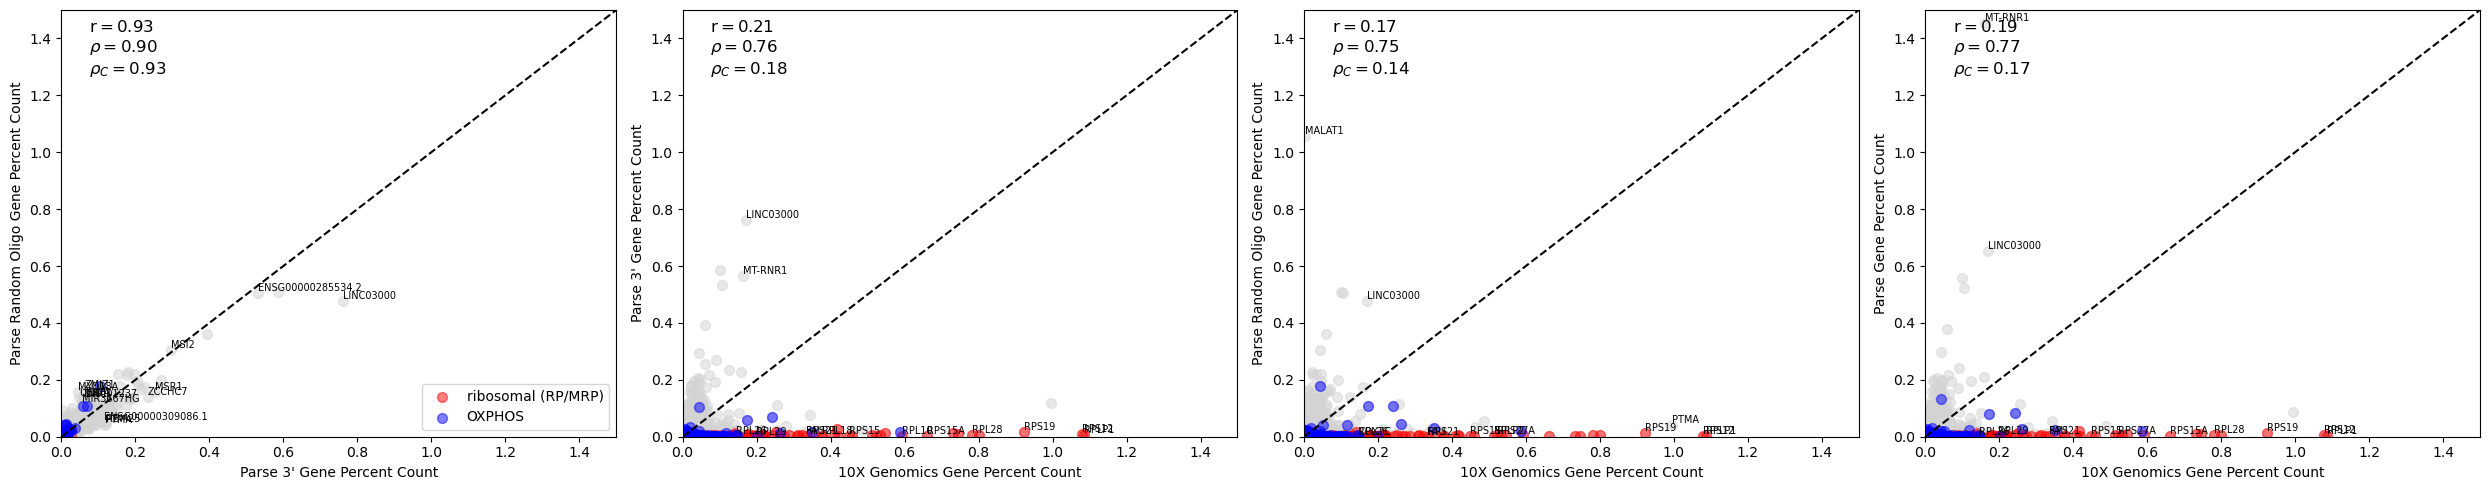

In [20]:
_, _ = plotting.compare(datasets, 1.5)

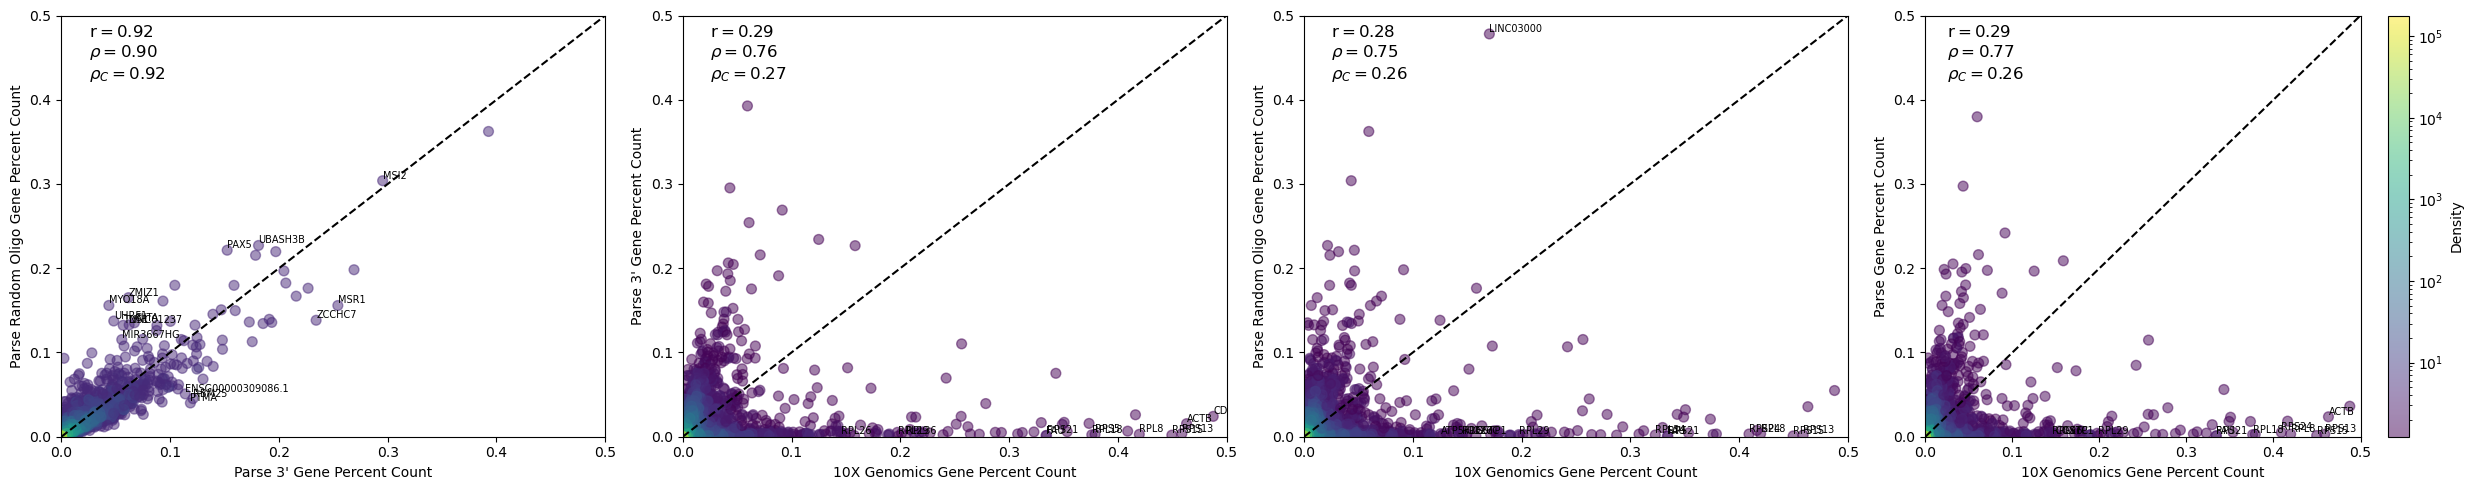

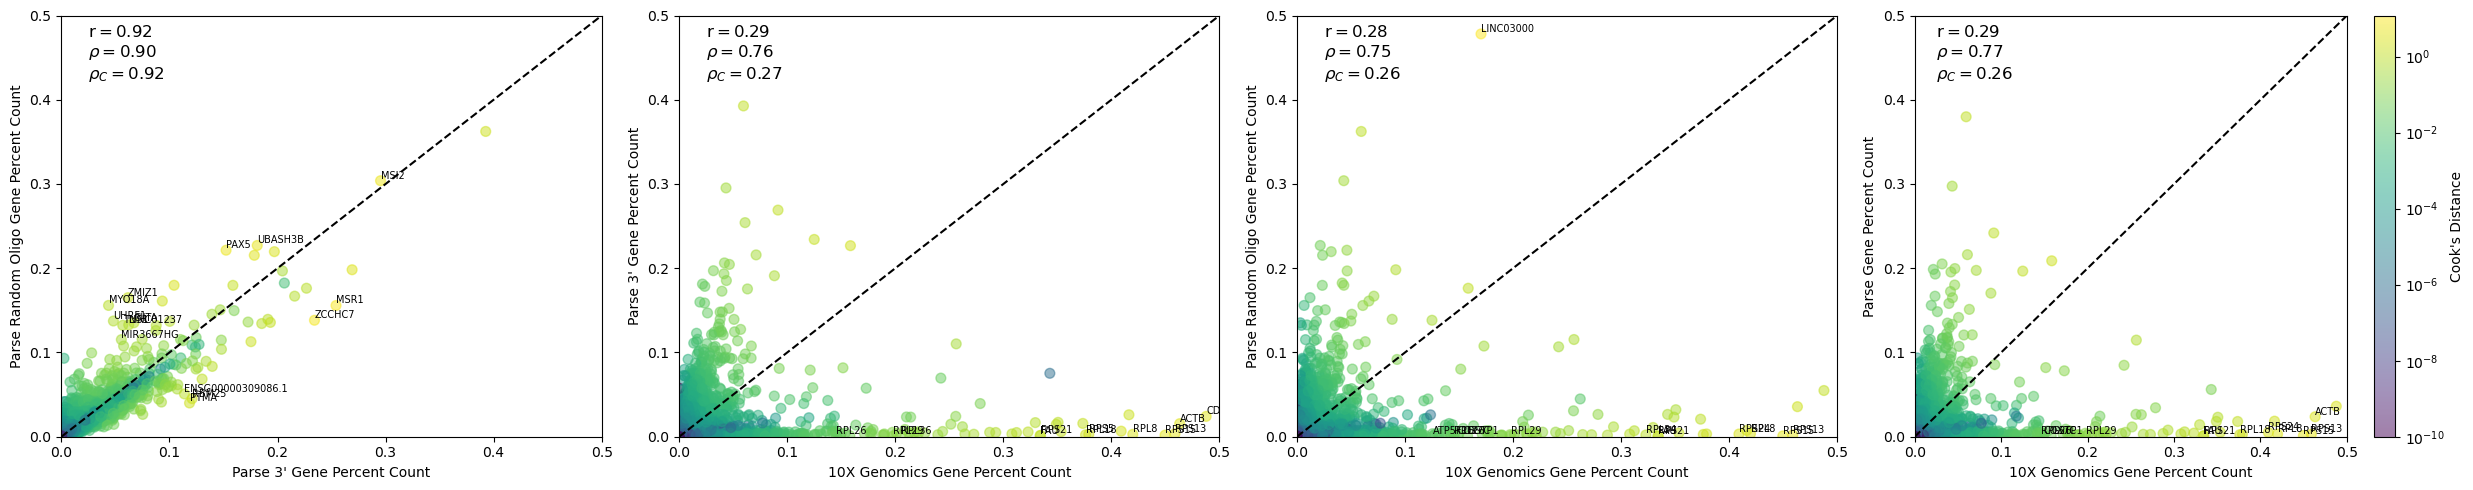

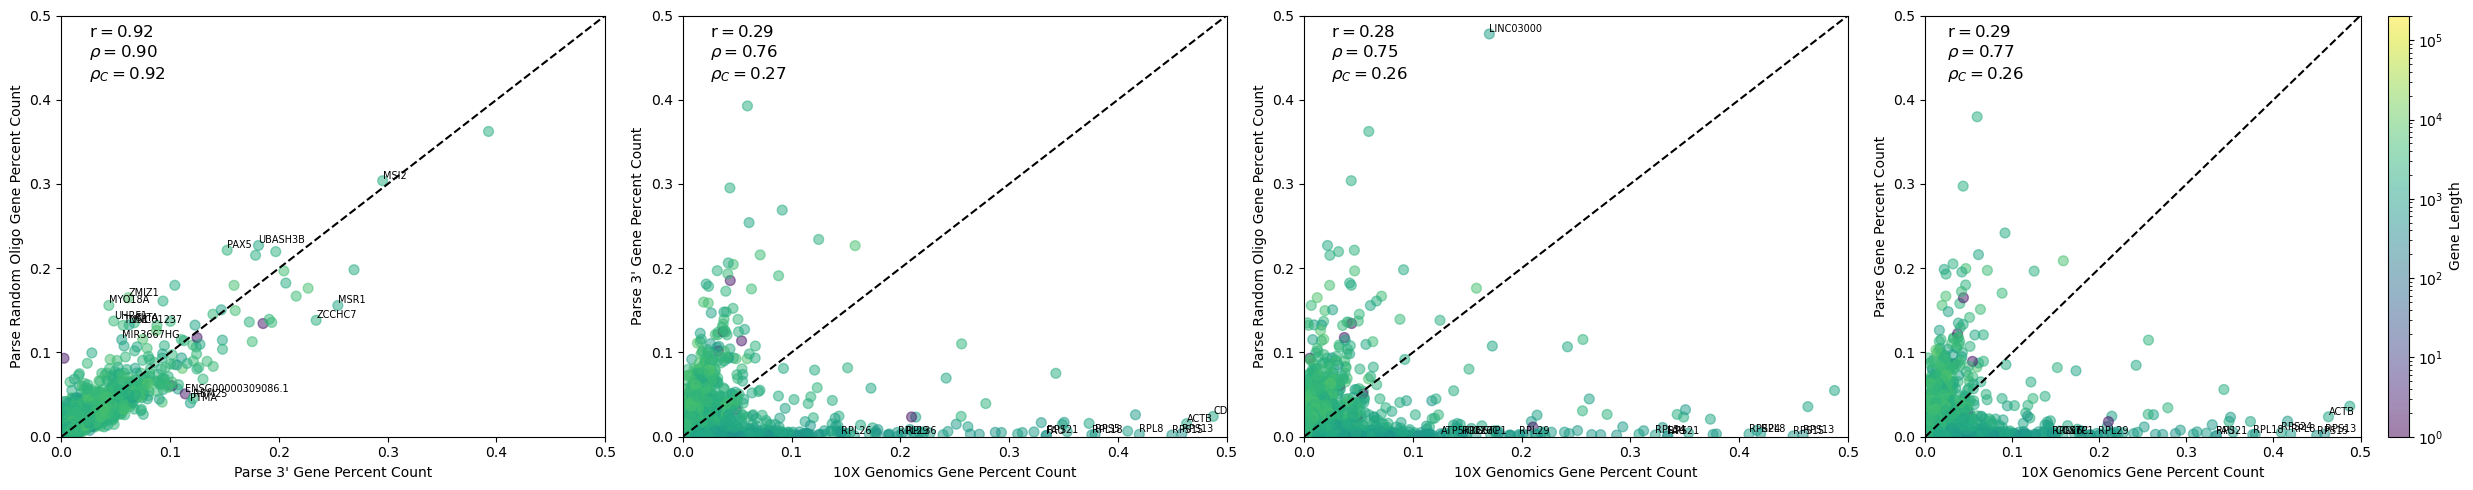

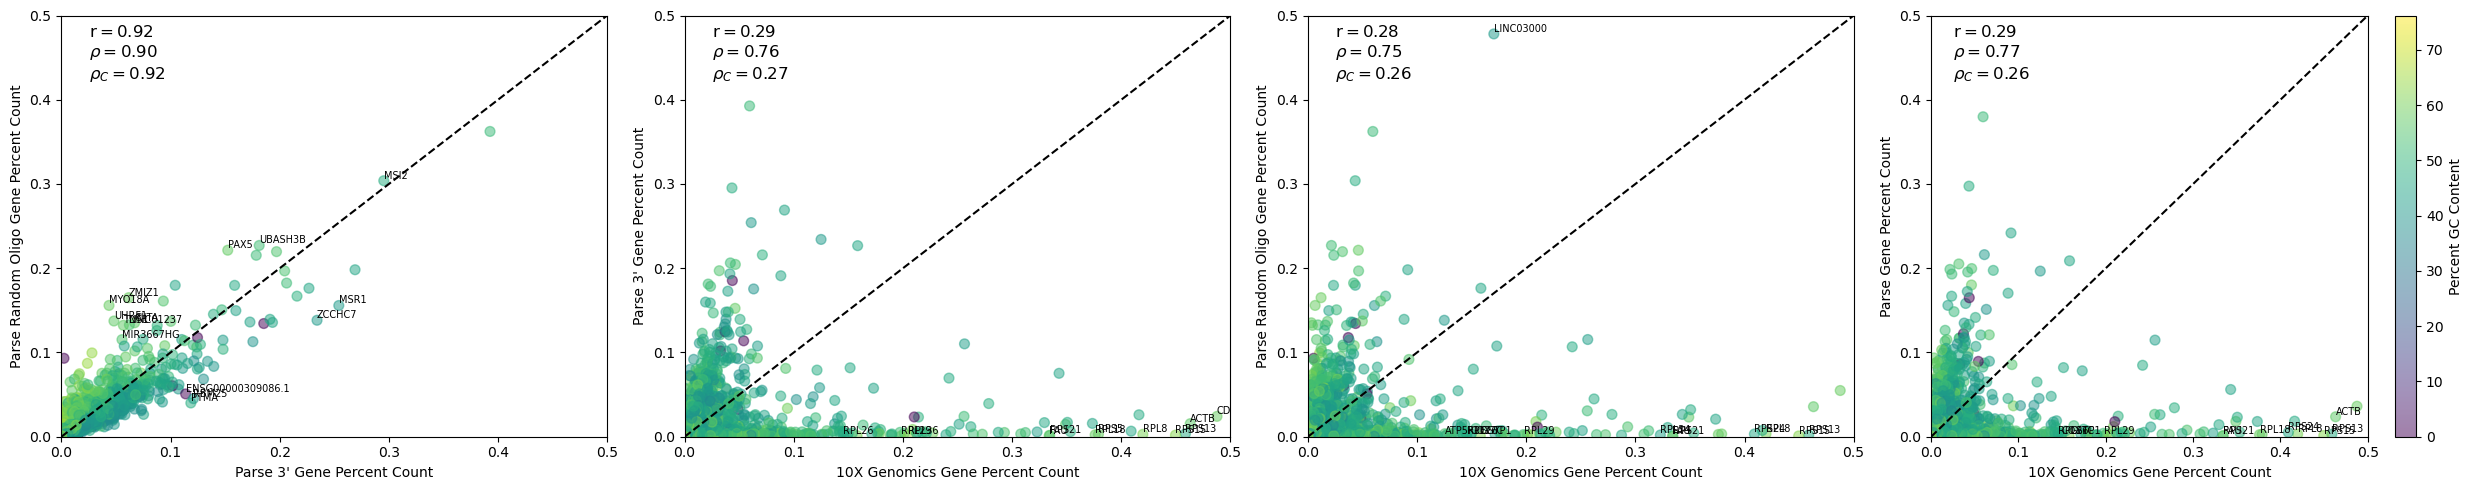

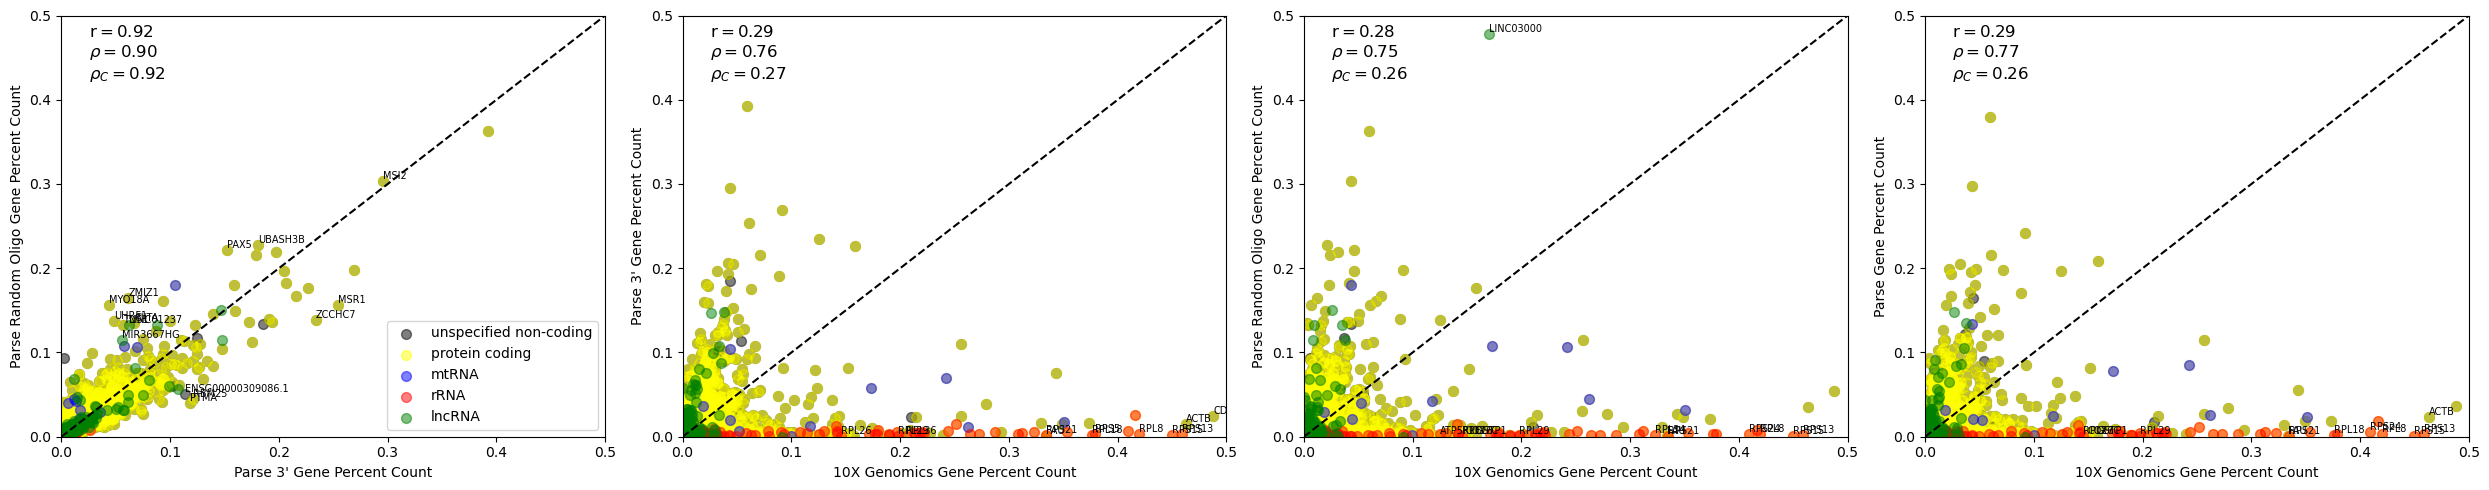

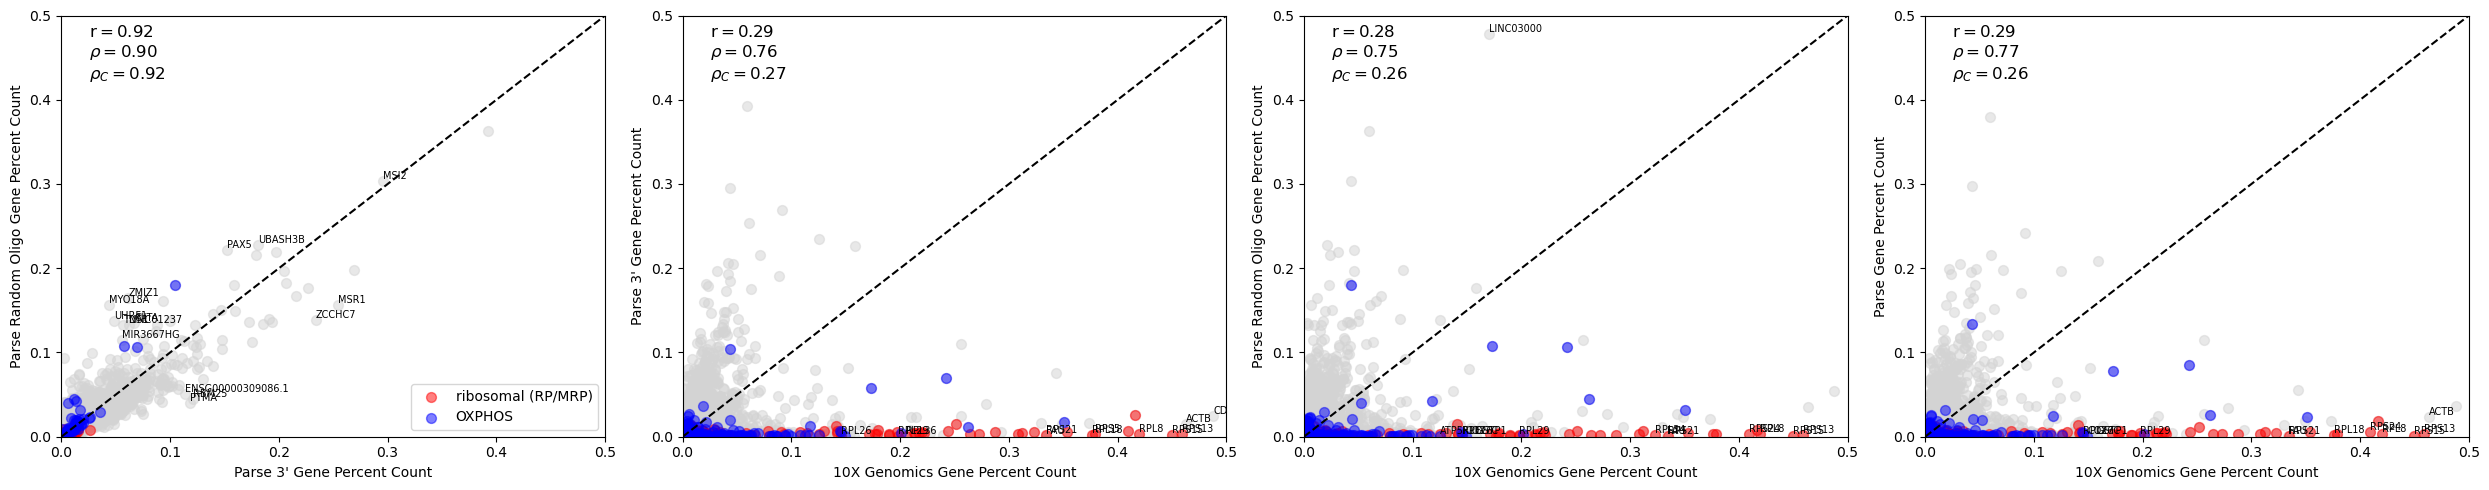

In [21]:
_, _ = plotting.compare(datasets, 0.5)

In [22]:
for name, df in zip(compare_names, compare_dfs):
    gene_info = plotting.merge_by_cooks(gene_info, name, df)

full_gene_info_path = 'gene_data/gene_comparisons.csv'
gene_info.to_csv(full_gene_info_path)

In [23]:
cell_thresh = 10

contents = plotting.generate_upset(datasets, gene_info, cell_thresh)

In [24]:
# Extract gene subsets that were interesting in the upset plot

genes_10x = contents['gene_ids'][contents['10x']& 
                                 ~contents['polyT']&
                                 ~contents['randO']&
                                 ~contents['parse']]
genes_10x = genes_10x.tolist()

genes_PO = contents['gene_ids'][~contents['10x']& 
                                ~contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_PO = genes_PO.tolist()

genes_POT = contents['gene_ids'][~contents['10x']& 
                                contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_POT = genes_POT.tolist()

genes_all = contents['gene_ids'][contents['10x']& 
                                contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_all = genes_all.tolist()

set_names = ['10X', 'Parse and Parse Random Oligo', 'Parse, and Parse Random Oligo, and Parse PolyT', 'All Methods']
gene_sets = [genes_10x, genes_PO, genes_POT, genes_all]
cols = ['is_pc', 'is_lnc', 'is_mito', 'is_ribo']
col_names = ['protein-coding count', 'lncRNA count', 'mtRNA count', 'rRNA count']
color = ['yellow', 'blue', 'red', 'green']

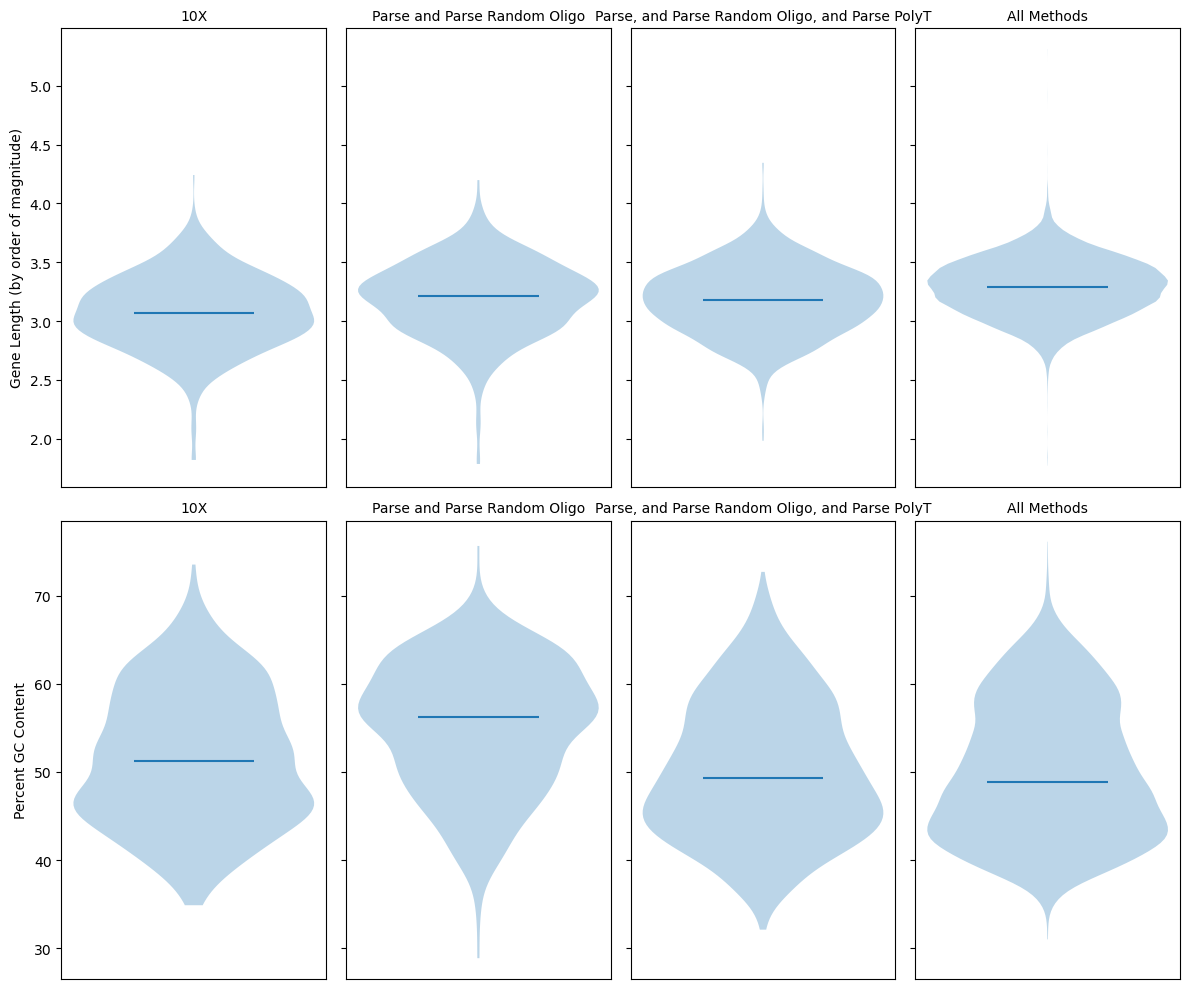

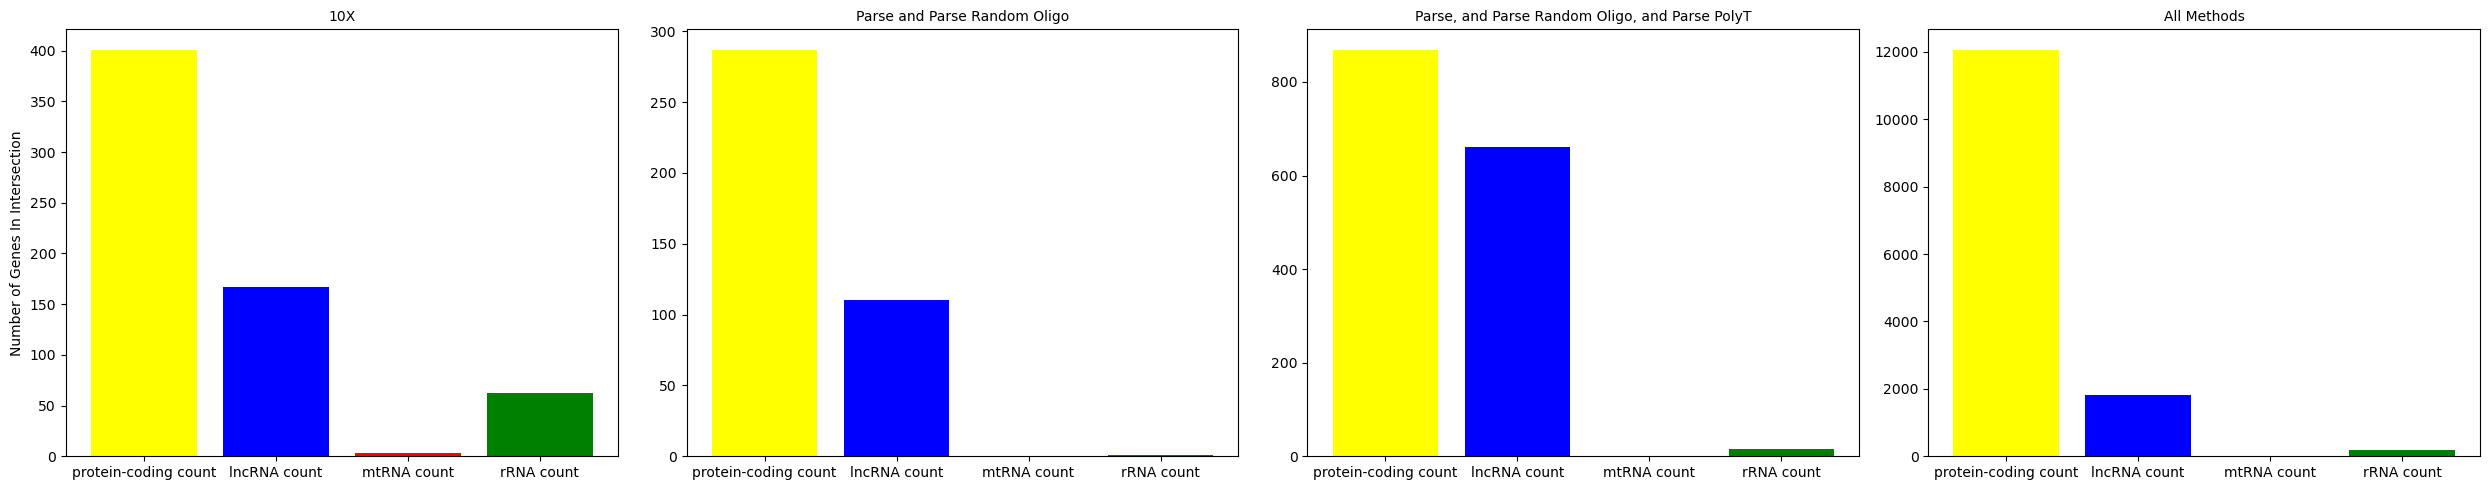

In [25]:
plotting.plot_geneset_metrics(gene_sets, set_names, gene_info)
plotting.plot_genetype_counts(gene_sets, set_names, cols, col_names, color, gene_info)

In [26]:
# Look at top 1000 genes for each method instead of all
contents = plotting.generate_upset(datasets, gene_info, cell_thresh, n_top_genes=1000)

In [27]:
genes_10x = contents['gene_ids'][contents['10x']& 
                                 ~contents['polyT']&
                                 ~contents['randO']&
                                 ~contents['parse']]
genes_10x = genes_10x.tolist()

genes_POT = contents['gene_ids'][~contents['10x']& 
                                contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_POT = genes_POT.tolist()

genes_all = contents['gene_ids'][contents['10x']& 
                                contents['polyT']&
                                contents['randO']&
                                contents['parse']]
genes_all = genes_all.tolist()

geneset_names = ['10X', 'Parse Methods', 'All Methods']
genesets = [genes_10x, genes_POT, genes_all]
cols = ['is_pc', 'is_lnc', 'is_mito', 'is_ribo']
col_names = ['protein-coding count', 'lncRNA count', 'mtRNA count', 'rRNA count']
color = ['yellow', 'blue', 'red', 'green']

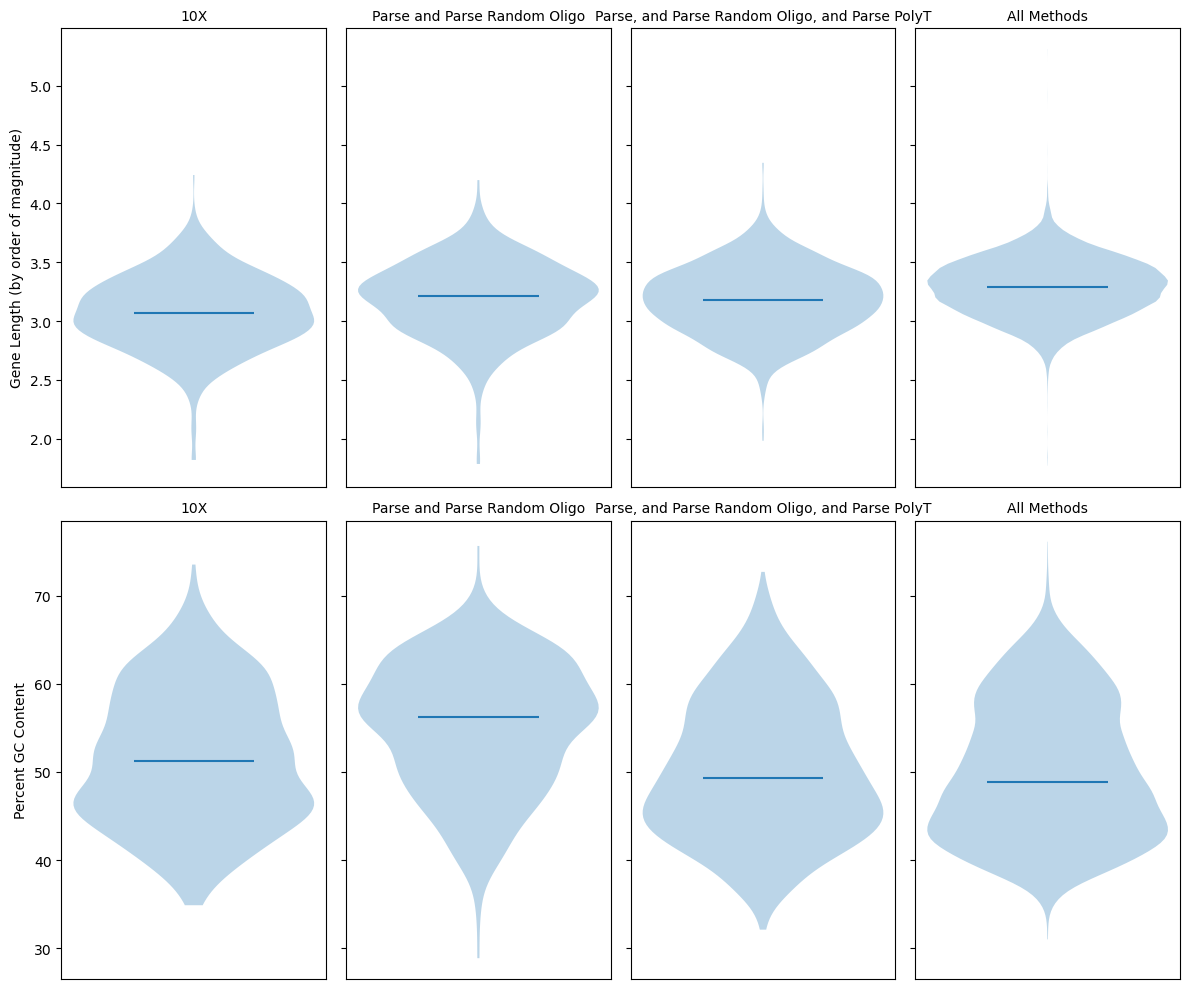

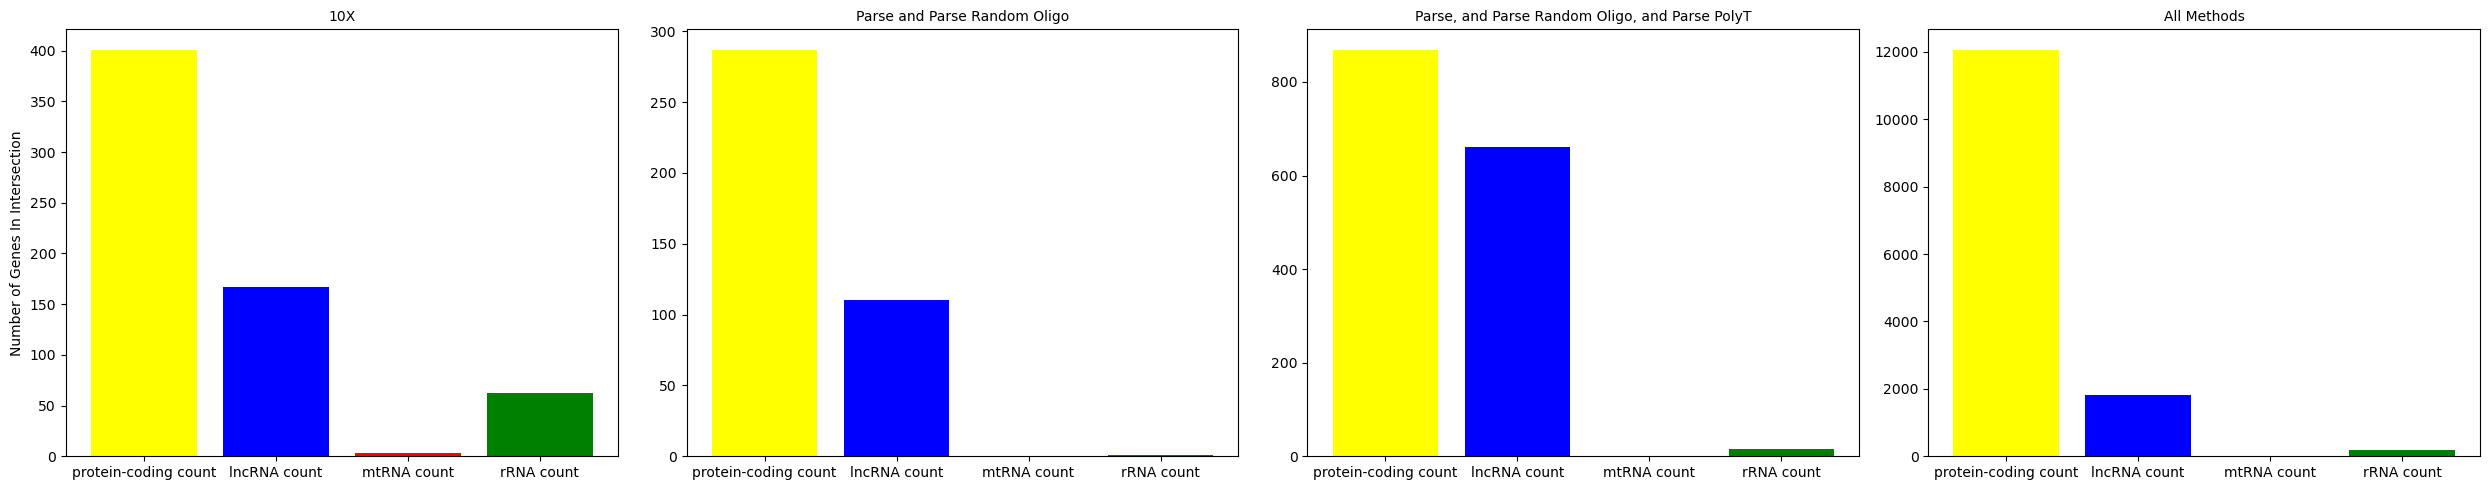

In [28]:
plotting.plot_geneset_metrics(gene_sets, set_names, gene_info)
plotting.plot_genetype_counts(gene_sets, set_names, cols, col_names, color, gene_info)